In [ ]:
#Disgenet data

In [1]:
import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')
print(df)

if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:

    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")
# Extract gene and score
result = df[['gene_symbol', score_col]]

# Sort by score in descending order
result = result.sort_values(by=score_col, ascending=False)

# Display the result
print(result)

# Save to a CSV file
result.to_csv('mdd_genes_with_scores.csv', index=False)

import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Filter for genes with score >= 0.7
high_score_genes = df[df[score_col] >= 0.70].copy()

# Extract gene and score
filtered_result = high_score_genes[['gene_symbol', score_col]]

# Sort by score in descending order
filtered_result = filtered_result.sort_values(by=score_col, ascending=False)

# Display the result
print(f"Found {len(filtered_result)} genes with score >= 0.70")
#print((filtered_result))

pd.set_option('display.max_rows', None)

# Print only the desired columns
print(filtered_result)
# Save to a CSV file
#filtered_result.to_csv('mdd_genes_high_score.csv', index=False)

#Add a label column
filtered_result['MDD_Label'] = 'High_Confidence_MDD_Gene'

# Save the labeled version
#result.to_csv('mdd_genes_high_score_labeled.csv', index=False)

           ei  numCTs                                       pathway_name  \
0    0.903846       2                                Signal Transduction   
1    0.830645      68  Signal Transduction,Disease,Immune System,Meta...   
2    0.871642      64  Signal Transduction,Disease,Gene expression (T...   
3    0.855556       6                                    Neuronal System   
4    0.764151      44                                      Immune System   
..        ...     ...                                                ...   
224  1.000000       0                                                NaN   
225  1.000000       0                                                NaN   
226  1.000000       0                              Developmental Biology   
227  1.000000       0          Developmental Biology,Signal Transduction   
228  1.000000       0  Metabolism of proteins,Cellular responses to s...   

    gene_symbol  numVariantsAssociatedToGene              gp_class_names  \
0         H

In [2]:
#Gene Score Analysis

COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES

1. BASIC STATISTICS
----------------------------------------
Total number of genes: 229
Average score: 0.624
Median score: 0.600
Score standard deviation: 0.119
Minimum score: 0.500
Maximum score: 0.950

2. SCORE DISTRIBUTION BY QUANTILES
----------------------------------------
25th percentile: 0.500
50th percentile: 0.600
75th percentile: 0.700
90th percentile: 0.800
95th percentile: 0.850

3. GENE COUNT BY SCORE THRESHOLDS
----------------------------------------
Genes with score ≥ 0.3: 229 (100.0%)
Genes with score ≥ 0.5: 229 (100.0%)
Genes with score ≥ 0.7: 62 (27.1%)
Genes with score ≥ 0.8: 33 (14.4%)
Genes with score ≥ 0.9: 6 (2.6%)

4. TOP 10 HIGHEST SCORING GENES
----------------------------------------
HTR1A: 0.950
IL6: 0.950
BDNF: 0.950
SLC6A4: 0.950
CRP: 0.950
GRM5: 0.900
CRH: 0.850
CYP2C19: 0.850
CYP2D6: 0.850
NR3C1: 0.850

5. GENERATING VISUALIZATIONS
----------------------------------------
Visualizations saved as 'mdd_genes

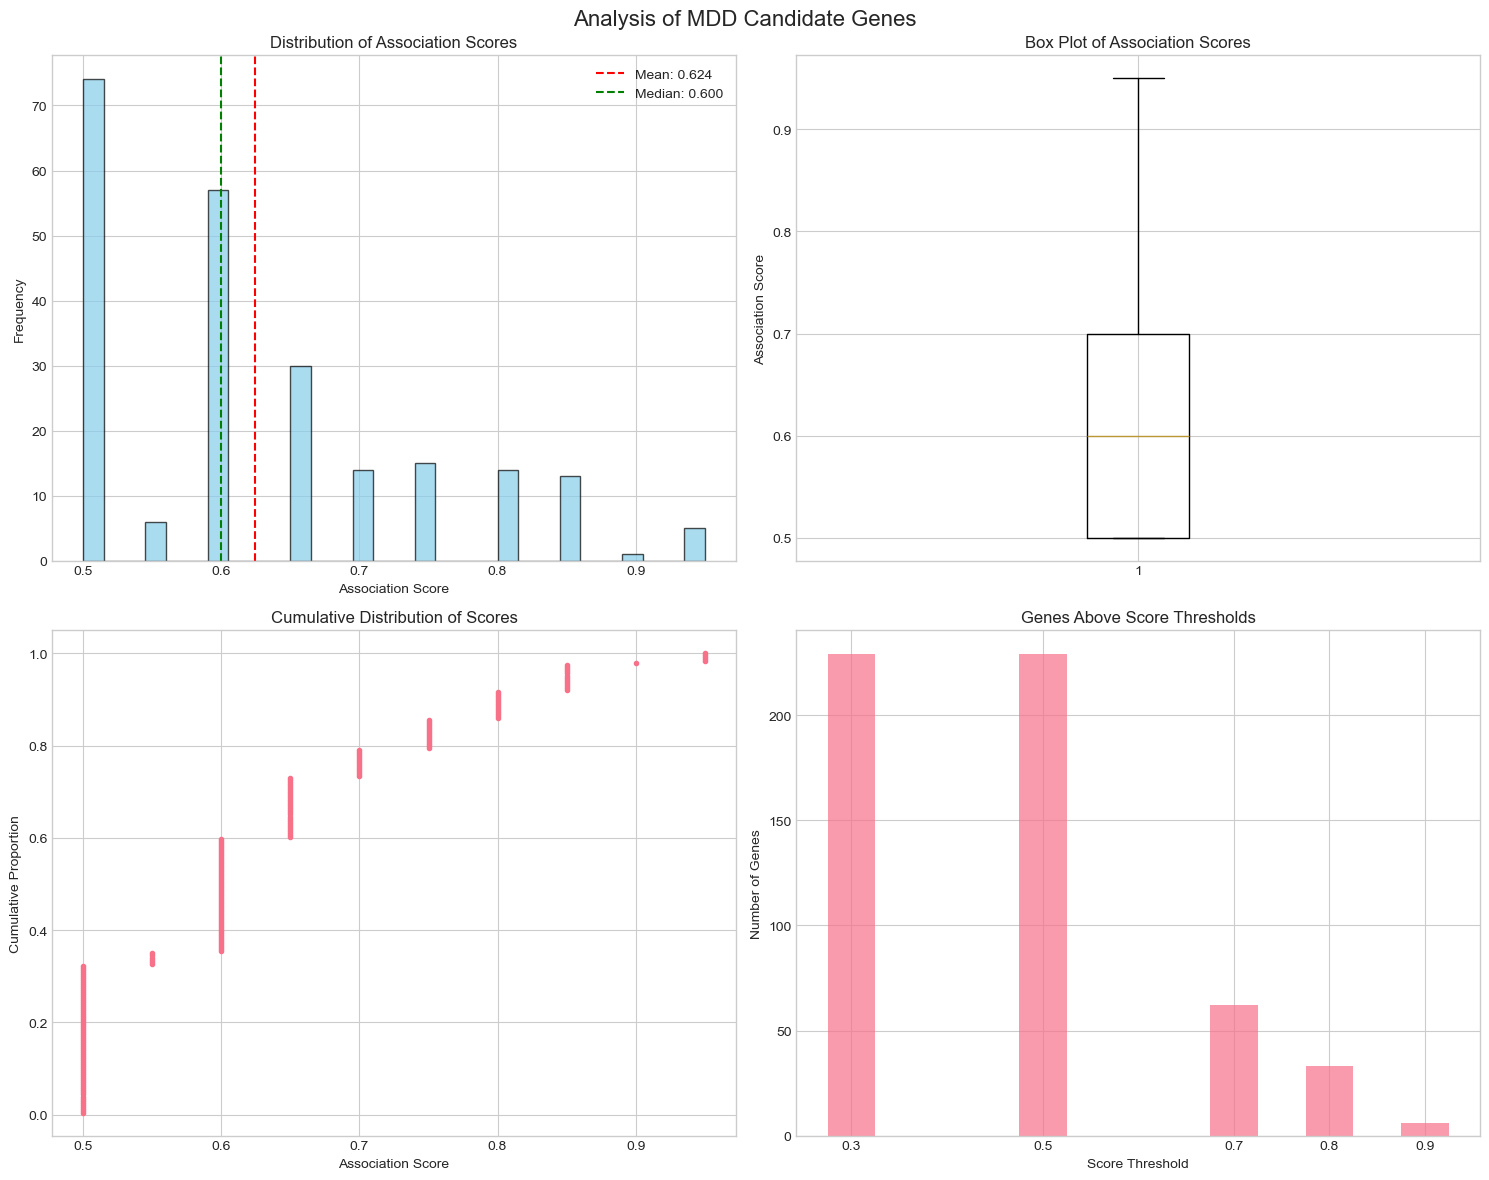

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def analyze_mdd_genes(df, score_column='score'):
    """
    Perform comprehensive analysis on MDD candidate genes
    
    Parameters:
    df (DataFrame): DataFrame containing MDD genes and their scores
    score_column (str): Name of the column containing association scores
    """
    
    print("=" * 60)
    print("COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES")
    print("=" * 60)
    
    # 1. Basic statistics
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    print(f"Total number of genes: {len(df)}")
    print(f"Average score: {df[score_column].mean():.3f}")
    print(f"Median score: {df[score_column].median():.3f}")
    print(f"Score standard deviation: {df[score_column].std():.3f}")
    print(f"Minimum score: {df[score_column].min():.3f}")
    print(f"Maximum score: {df[score_column].max():.3f}")
    
    # 2. Score distribution by quantiles
    print("\n2. SCORE DISTRIBUTION BY QUANTILES")
    print("-" * 40)
    quantiles = df[score_column].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
    for q, value in quantiles.items():
        print(f"{int(q*100)}th percentile: {value:.3f}")
    
    # 3. Count genes by score thresholds
    print("\n3. GENE COUNT BY SCORE THRESHOLDS")
    print("-" * 40)
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    for threshold in thresholds:
        count = len(df[df[score_column] >= threshold])
        print(f"Genes with score ≥ {threshold}: {count} ({count/len(df)*100:.1f}%)")
    
    # 4. Top 10 highest scoring genes
    print("\n4. TOP 10 HIGHEST SCORING GENES")
    print("-" * 40)
    top_genes = df.nlargest(10, score_column)[['gene_symbol', score_column]]
    for _, row in top_genes.iterrows():
        print(f"{row['gene_symbol']}: {row[score_column]:.3f}")
    
    # 5. Visualizations
    print("\n5. GENERATING VISUALIZATIONS")
    print("-" * 40)
    
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of MDD Candidate Genes', fontsize=16)
    
    # Distribution of scores
    axes[0, 0].hist(df[score_column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df[score_column].mean(), color='red', linestyle='--', label=f'Mean: {df[score_column].mean():.3f}')
    axes[0, 0].axvline(df[score_column].median(), color='green', linestyle='--', label=f'Median: {df[score_column].median():.3f}')
    axes[0, 0].set_xlabel('Association Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Association Scores')
    axes[0, 0].legend()
    
    # Box plot of scores
    axes[0, 1].boxplot(df[score_column])
    axes[0, 1].set_ylabel('Association Score')
    axes[0, 1].set_title('Box Plot of Association Scores')
    
    # Cumulative distribution
    sorted_scores = np.sort(df[score_column])
    cum_dist = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
    axes[1, 0].plot(sorted_scores, cum_dist, marker='.', linestyle='none')
    axes[1, 0].set_xlabel('Association Score')
    axes[1, 0].set_ylabel('Cumulative Proportion')
    axes[1, 0].set_title('Cumulative Distribution of Scores')
    axes[1, 0].grid(True)
    
    # Score thresholds
    threshold_counts = [len(df[df[score_column] >= t]) for t in thresholds]
    axes[1, 1].bar(thresholds, threshold_counts, width=0.05, alpha=0.7)
    axes[1, 1].set_xlabel('Score Threshold')
    axes[1, 1].set_ylabel('Number of Genes')
    axes[1, 1].set_title('Genes Above Score Thresholds')
    axes[1, 1].set_xticks(thresholds)
    
    plt.tight_layout()
    plt.savefig('mdd_genes_analysis.png', dpi=300, bbox_inches='tight')
    print("Visualizations saved as 'mdd_genes_analysis.png'")
    
    # 6. Additional analyses
    if 'Gene Type' in df.columns:
        print("\n6. GENE TYPE DISTRIBUTION")
        print("-" * 40)
        gene_type_counts = df['Gene Type'].value_counts()
        print("Top gene types:")
        for gene_type, count in gene_type_counts.head(10).items():
            print(f"  {gene_type}: {count} genes")
            
        # Plot gene type distribution
        plt.figure(figsize=(10, 6))
        gene_type_counts.head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top 10 Gene Types in MDD Candidates')
        plt.xlabel('Gene Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('mdd_gene_types.png', dpi=300, bbox_inches='tight')
        print("Gene type distribution saved as 'mdd_gene_types.png'")
    
    if 'Pathways' in df.columns:
        print("\n7. PATHWAY ANALYSIS")
        print("-" * 40)
        # Extract and count pathways
        all_pathways = []
        for pathways in df['Pathways'].dropna():
            # Assuming pathways are separated by semicolons
            pathway_list = [p.strip() for p in pathways.split(';')]
            all_pathways.extend(pathway_list)
        
        pathway_counts = pd.Series(all_pathways).value_counts()
        print("Top pathways associated with MDD genes:")
        for pathway, count in pathway_counts.head(10).items():
            print(f"  {pathway}: {count} genes")
    
    # 8. Save detailed analysis results
    analysis_results = {
        'total_genes': len(df),
        'mean_score': df[score_column].mean(),
        'median_score': df[score_column].median(),
        'std_score': df[score_column].std(),
        'min_score': df[score_column].min(),
        'max_score': df[score_column].max(),
        'quantiles': quantiles.to_dict(),
        'threshold_counts': {f"geq_{t}": len(df[df[score_column] >= t]) for t in thresholds},
        'top_genes': top_genes.to_dict('records')
    }
    
    # Convert to DataFrame and save
    analysis_df = pd.DataFrame.from_dict(analysis_results, orient='index')
    analysis_df.to_csv('mdd_genes_analysis_summary.csv', header=['Value'])
    print("\nAnalysis summary saved as 'mdd_genes_analysis_summary.csv'")
    
    return analysis_results

# Load the  data
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Run the analysis
analysis_results = analyze_mdd_genes(df, score_col)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

In [7]:
#aggregating nodes + builing network

In [9]:
import pandas as pd

pd.reset_option('display.max_rows')

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_97.tsv" 
brain_only_df = pd.read_csv(file_path, sep='\t')


brain_only_df = brain_only_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain:")
print(brain_only_df)

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_restrictedbrain.tsv" 
brain_restricted_df = pd.read_csv(file_path, sep='\t')


brain_restricted_df = brain_restricted_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain and in less than 1/3 of other tissues:")
print(brain_restricted_df)


# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_all_tissues.tsv" 
all_tissues_df = pd.read_csv(file_path, sep='\t')


all_tissues_df = all_tissues_df[['Gene']]


# Display the result
print("The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):")
print(all_tissues_df)



print('List of common genes between all MDD genes and the genes only existing in brain are:')
common_df = result[result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes only existing in brain are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in less than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes existing brain and less than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))

print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in more than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes in more than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))



#concat MDD genes with Brain genes
import pandas as pd

print("Node set 1 contains the restricted genes (Genes in brain and less than 1/3 of all tissues + Genes only in brain:)")
node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        result['gene_symbol'], 
        brain_restricted_df['Gene']
    ], ignore_index=True)
})

node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        node_set1['Genes'], 
        brain_only_df['Gene']
    ], ignore_index=True)
})
print(node_set1)


print("----------------------")
print("\n")

print("Node set 2 contains the all brain genes (And all other tissues))")
node_set2 = pd.DataFrame({
    'Genes': pd.concat([
        all_tissues_df['Gene'], 
        node_set1['Genes']
    ], ignore_index=True)
})
print(node_set2)

print("----------------------")
print("\n")

print("Here the node set is assigned to the nodes in our network: ")
all_nodes = node_set1

print(all_nodes)



import requests

# Gene list
gene_list = all_nodes['Genes'].dropna().unique().tolist()
print(f"Number of input genes: {len(gene_list)}")

# STRING API settings
STRING_API_URL = "https://string-db.org/api/tsv-no-header/network"
payload = {
    "identifiers": "\n".join(gene_list),  # newline-separated
    "species": 9606,
    "required_score": 400
}

# Use POST to avoid URL length limit
response = requests.post(STRING_API_URL, data=payload)

if response.ok:
    interactions = []
    for line in response.text.strip().split("\n"):
        cols = line.split("\t")
        try:
            gene_a = cols[2]  # preferredName_A
            gene_b = cols[3]  # preferredName_B
            
            score = float(cols[5])  # combined_score
            interactions.append((gene_a, gene_b, score))
           # print(interactions)
        except (IndexError, ValueError):
            continue
    print(f"Number of interactions found: {len(interactions)}")
else:
    print("Error:", response.status_code, response.text)

for i in range(0,10):
    print(interactions[i])


import networkx as nx

G = nx.Graph()

# Add nodes
G.add_nodes_from(gene_list)

# Add edges with STRING score as weight
for gene_a, gene_b, score in interactions:
    G.add_edge(gene_a, gene_b, weight=score)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

print(min(w for _,_,w in interactions), max(w for _,_,w in interactions))


The genes that only exist in human's brain:
              Gene
0             AMBN
1             AMZ1
2         ANKRD34C
3          ANKRD63
4   ARMCX5-GPRASP2
..             ...
92        TMEM132D
93           TRPC5
94            UCMA
95            VAX1
96            WNT1

[97 rows x 1 columns]
The genes that only exist in human's brain and in less than 1/3 of other tissues:
         Gene
0       A2ML1
1      ABCC12
2       ABCG4
3     ABHD12B
4        ACAN
...       ...
1359   ZNF732
1360  ZNF804A
1361   ZNF831
1362   ZNF843
1363      ZP2

[1364 rows x 1 columns]
The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):
        Gene
0     A4GALT
1      AADAT
2       AARD
3       AASS
4       AATK
...      ...
4966  ZSWIM4
4967  ZSWIM5
4968  ZSWIM9
4969   ZWINT
4970    ZXDA

[4971 rows x 1 columns]
List of common genes between all MDD genes and the genes only existing in brain are:
    gene_symbol  score
93         DRD3    0.6
111       HTR3B    0.6
118  

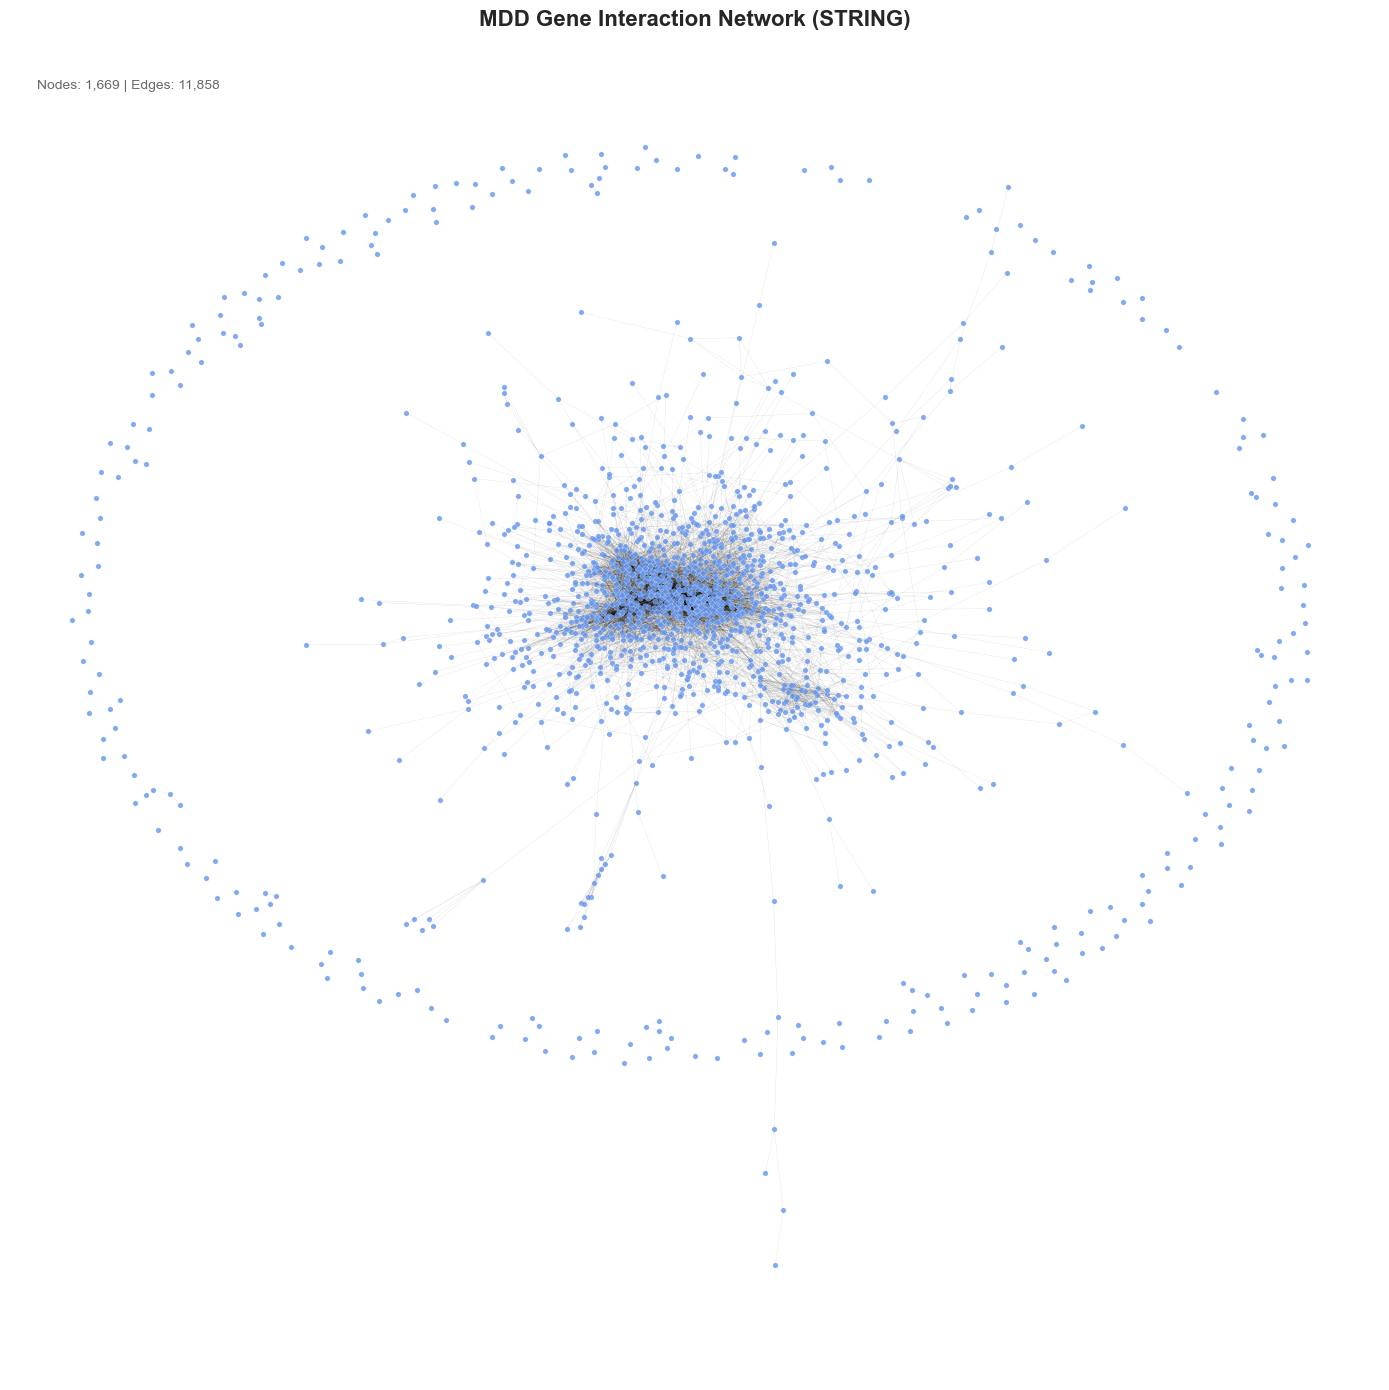

In [11]:
#Graph!
import matplotlib.pyplot as plt
import networkx as nx


plt.style.use("seaborn-v0_8-white")

# Create the layout (spring layout can be slow, so this uses fewer iterations)
pos = nx.spring_layout(G, k=0.08, iterations=50, seed=42)

# Initialize figure
plt.figure(figsize=(14, 14))
plt.title("MDD Gene Interaction Network (STRING)", fontsize=16, fontweight='bold', pad=20)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=15,
    node_color="cornflowerblue",
    alpha=0.8,
    linewidths=0.2,
    edgecolors="white"
)

# Draw edges (thin and transparent for clarity)
nx.draw_networkx_edges(
    G, pos,
    width=0.2,
    alpha=0.15,
    edge_color="black"
)

# Remove axes for a clean look
plt.axis("off")

# Add annotation for node/edge count
plt.text(0.02, 0.98,
         f"Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}",
         transform=plt.gca().transAxes,
         fontsize=10, color="dimgray", va="top")

plt.tight_layout()
plt.show()


Initial connected STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
Scoring table built: 934 nodes (positives=60)

NEGATIVE SELECTION (30 samples; criteria identical, seed varies)
- Non-positives count: 874
- Bottom quantile q=0.5: cutoff=0.284260
- Exclude dist <= 2: ON
- Eligible negatives: 215
- Selected negatives per sample: 60 (target=60)
- Positives in graph: 60
  sample 00 seed=42: size=60 | outside_eligible=0 | overlap_positives=0
  sample 01 seed=43: size=60 | outside_eligible=0 | overlap_positives=0
  sample 02 seed=44: size=60 | outside_eligible=0 | overlap_positives=0
  sample 03 seed=45: size=60 | outside_eligible=0 | overlap_positives=0
  sample 04 seed=46: size=60 | outside_eligible=0 | overlap_positives=0
  sample 05 seed=47: size=60 | outside_eligible=0 | overlap_positives=0
  sample 06 seed=48

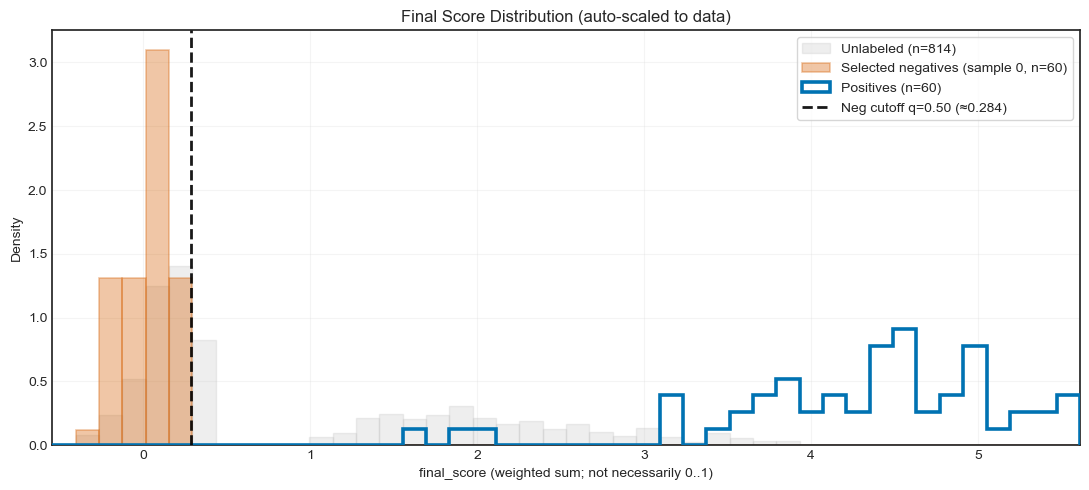

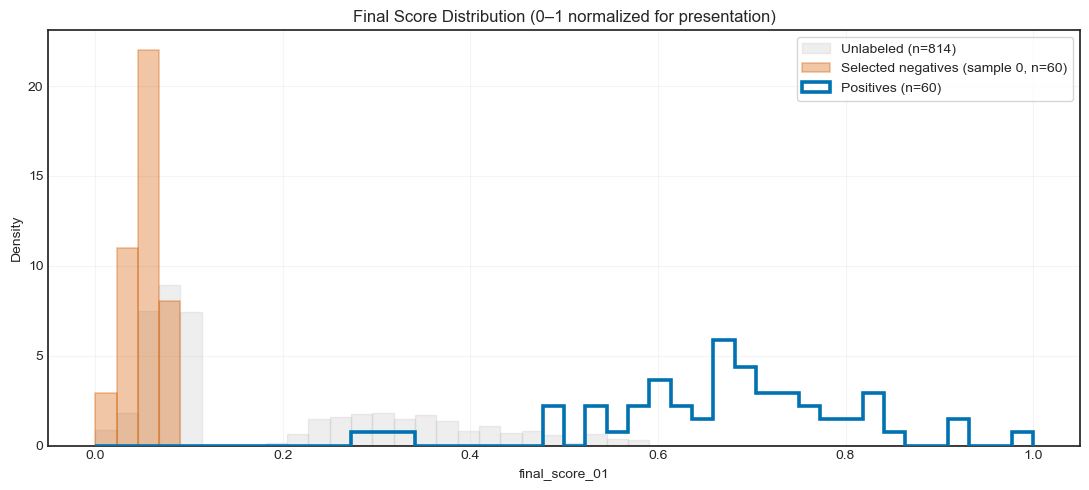

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_72302/1987793725.py:369: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


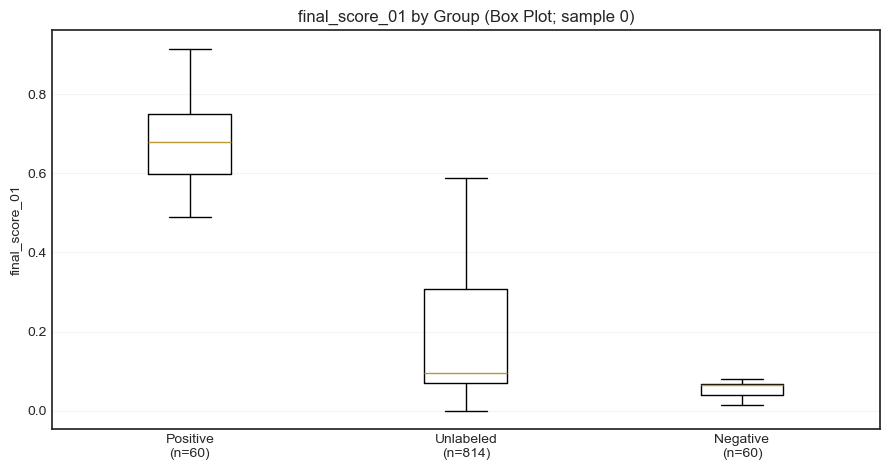


Saved:
- candidate_genes.csv (top 20 non-positive by final_score)
- refined_negative_genes_30samples_thr0.6_q0.5_excl2_k60.csv
- refined_negative_genes_SAMPLE0_thr0.6_q0.5_excl2.csv
- scored_all_nodes.csv (all nodes with features + scores + groups)


In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import random
from collections import deque

# =======================================================
# FULL PIPELINE: Heuristic Scoring + Negative Selection (30 samples)
#
# IMPORTANT:
# - negatives are sampled ONLY from non-positives
# - eligible pool = bottom NEG_Q of non-positive final_score
# -  exclude nodes within <= EXCLUDE_DIST hops of positives
#
# NEW IN THIS VERSION:
# 1) keep only the part of the graph that is connected to at least one positive gene
#    (remove components with no positive genes, since they do not help
#     positive-guided scoring or prioritization)
# 2) draw 30 negative samples instead of 10
#
# Outputs:
#   - scored (DataFrame with features + final_score)
#   - negative_gene_sets (list of 30 negative lists)
#   - negative_gene_sets_by_seed (dict seed -> negative list)
#   - negative_genes / negatives (sample 0, for compatibility with plotting)
# =======================================================

# -----------------------------
# Config
# -----------------------------
EDGE_THRESHOLD = 0.6

NEG_Q = 0.50
NEG_RATIO = 1.0
EXCLUDE_DIST = 2

N_NEG_SAMPLES = 30
BASE_SEED = 42

# Scoring weights (all features are MinMax-scaled first)
WEIGHTS = {
    "ppr": 3.0,
    "pos_w_ratio": 2.0,
    "pos_w_sum": 1.5,
    "pos_w_max": 1.0,
    "prox": 1.5,
    "hub_penalty": -1.0
}
PROX_ALPHA = 0.7

# -----------------------------
# Helpers
# -----------------------------
def multi_source_bfs_distances(G, sources):
    dist = {n: np.inf for n in G.nodes()}
    q = deque()
    for s in sources:
        if s in G:
            dist[s] = 0
            q.append(s)
    while q:
        u = q.popleft()
        for v in G.neighbors(u):
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def summarize_scores(name, arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        print(f"{name:10s}: n=0")
        return
    q01, q25, q50, q75, q99 = np.quantile(arr, [0.01, 0.25, 0.50, 0.75, 0.99])
    print(
        f"{name:10s}: n={arr.size:<6d} min={arr.min(): .6f}  p01={q01: .6f}  "
        f"p25={q25: .6f}  med={q50: .6f}  p75={q75: .6f}  p99={q99: .6f}  max={arr.max(): .6f}"
    )

def auto_bins(all_scores, n_bins=45):
    lo, hi = np.quantile(all_scores, [0.01, 0.99])
    if lo == hi:
        lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
    pad = 0.05 * (hi - lo + 1e-9)
    x_min, x_max = lo - pad, hi + pad
    bins = np.linspace(x_min, x_max, n_bins)
    return bins, x_min, x_max

# =======================================================
# 1) Build Weighted Network
# =======================================================
# EXPECTED INPUTS:
# - interactions: iterable of (geneA, geneB, weight)
# - filtered_result: DataFrame with column "gene_symbol" (positives)
high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

G = nx.Graph()
for a, b, w in high_conf_interactions:
    G.add_edge(str(a), str(b), weight=float(w))

print(f"Initial connected STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# =======================================================
# 2) Label Positive Genes
# =======================================================
positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
nx.set_node_attributes(G, {n: (1 if n in positive_genes else 0) for n in G.nodes()}, "positive")

pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in graph before component filtering: {len(pos_in_graph)}")

# =======================================================
# 3) Keep only nodes connected to at least one positive
# =======================================================
# Remove components that contain no positive genes.
# In the previous check, these were the genes disconnected from all positives,
# so they do not contribute meaningful positive-guided network scoring.
positive_nodes_set = set(pos_in_graph)

reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_nodes_set:
        reachable_from_positive.update(comp)

removed_nodes = set(G.nodes()) - reachable_from_positive
n_removed = len(removed_nodes)

G = G.subgraph(reachable_from_positive).copy()

print(f"Removed {n_removed} genes from components with no positive connection")
print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Recompute positives in the filtered graph
pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in filtered graph: {len(pos_in_graph)}")

# =======================================================
# 4) Precompute Global Signals
# =======================================================
dist_to_pos = multi_source_bfs_distances(G, pos_in_graph) if len(pos_in_graph) > 0 else {n: np.inf for n in G.nodes()}

if len(pos_in_graph) > 0:
    personalization = {n: (1.0 if n in pos_in_graph else 0.0) for n in G.nodes()}
    ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="weight")
else:
    ppr = {n: 0.0 for n in G.nodes()}

deg = dict(G.degree())

# =======================================================
# 5) Feature Table for ALL nodes (including positives)
# =======================================================
rows = []
eps = 1e-9

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    pos_neighbors = [n for n in neighbors if G.nodes[n].get("positive", 0) == 1]

    pos_edges = [G[node][p]["weight"] for p in pos_neighbors]
    pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
    pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
    pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
    pos_neighbor_count = len(pos_neighbors)

    total_w = float(np.sum([G[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
    pos_w_ratio = pos_w_sum / (total_w + eps)

    d = dist_to_pos.get(node, np.inf)
    prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    hub_penalty = float(np.log1p(deg.get(node, 0)))

    rows.append({
        "gene": node,
        "is_positive": int(G.nodes[node].get("positive", 0) == 1),
        "pos_neighbor_count": pos_neighbor_count,
        "pos_w_sum": pos_w_sum,
        "pos_w_max": pos_w_max,
        "pos_w_mean": pos_w_mean,
        "pos_w_ratio": pos_w_ratio,
        "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
        "prox": prox,
        "ppr": float(ppr.get(node, 0.0)),
        "hub_penalty": hub_penalty
    })

scored = pd.DataFrame(rows)
print(f"Scoring table built: {len(scored)} nodes (positives={int(scored['is_positive'].sum())})")

# =======================================================
# 6) Normalize features + Composite Final Score
# =======================================================
score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

# replace inf distance (distance is used only for exclusion later)
if np.isinf(scored["distance_to_positive"]).any():
    reachable = scored.loc[~np.isinf(scored["distance_to_positive"]), "distance_to_positive"]
    worst = float(reachable.max()) + 1 if len(reachable) else 1.0
    scored["distance_to_positive"] = scored["distance_to_positive"].replace(np.inf, worst)

scaler = MinMaxScaler()
scored[score_features] = scaler.fit_transform(scored[score_features])

scored["final_score"] = 0.0
for f, w in WEIGHTS.items():
    scored["final_score"] += scored[f] * float(w)

scored["final_score_01"] = MinMaxScaler().fit_transform(scored[["final_score"]])

scored["group"] = "unlabeled"
scored.loc[scored["is_positive"] == 1, "group"] = "positive"

# =======================================================
# 7) Choose Negatives (ONLY from non-positives) - 30 samples
# =======================================================
nonpos = scored[scored["is_positive"] == 0].copy()

cutoff = nonpos["final_score"].quantile(NEG_Q)
eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
    eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

eligible_genes = eligible["gene"].tolist()

k_target = int(np.ceil(NEG_RATIO * max(1, len(pos_in_graph))))
k = min(k_target, len(eligible_genes))

negative_gene_sets = []
negative_gene_sets_by_seed = {}

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    rng = random.Random(seed_i)
    neg_i = rng.sample(eligible_genes, k=k) if k > 0 else []
    negative_gene_sets.append(neg_i)
    negative_gene_sets_by_seed[seed_i] = neg_i

# Use sample 0 for plots / compatibility
negatives = negative_gene_sets[0]
negative_genes = negatives

scored.loc[scored["gene"].isin(negatives), "group"] = "negative"

print(f"\nNEGATIVE SELECTION ({N_NEG_SAMPLES} samples; criteria identical, seed varies)")
print(f"- Non-positives count: {len(nonpos)}")
print(f"- Bottom quantile q={NEG_Q}: cutoff={cutoff:.6f}")
print(f"- Exclude dist <= {EXCLUDE_DIST}: {'ON' if EXCLUDE_DIST and EXCLUDE_DIST > 0 else 'OFF'}")
print(f"- Eligible negatives: {len(eligible_genes)}")
print(f"- Selected negatives per sample: {k} (target={k_target})")
print(f"- Positives in graph: {len(pos_in_graph)}")

eligible_set = set(map(str, eligible_genes))
pos_set = set(map(str, pos_in_graph))

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    neg_set = set(map(str, negative_gene_sets[i]))
    outside = len(neg_set - eligible_set)
    overlap_pos = len(neg_set & pos_set)
    print(f"  sample {i:02d} seed={seed_i}: size={len(neg_set)} | outside_eligible={outside} | overlap_positives={overlap_pos}")

# =======================================================
# 8) Print summaries (sample 0)
# =======================================================
pos_scores = scored.loc[scored["group"] == "positive", "final_score"].values
neg_scores = scored.loc[scored["group"] == "negative", "final_score"].values
unl_scores = scored.loc[scored["group"] == "unlabeled", "final_score"].values
all_scores = scored["final_score"].values

print("\n=== SCORE RANGES (final_score) ===")
summarize_scores("ALL", all_scores)
summarize_scores("POS", pos_scores)
summarize_scores("NEG", neg_scores)
summarize_scores("UNLABELED", unl_scores)

print("\n=== CONSISTENCY CHECKS ===")
print("Any positives selected as negative? ->", bool(set(negatives) & set(pos_in_graph)))
print("Counts by group (sample 0):")
print(scored["group"].value_counts().to_string())

print("\n=== TOP 10 POSITIVES by final_score ===")
print(
    scored[scored["group"] == "positive"]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

print("\n=== TOP 10 NON-POSITIVES by final_score ===")
print(
    scored[scored["is_positive"] == 0]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

# =======================================================
# 9) Visualize (sample 0 groups)
# =======================================================
COL_UNL = "#BDBDBD"
COL_NEG = "#D55E00"
COL_POS = "#0072B2"
COL_CUT = "#000000"

bins, x_min, x_max = auto_bins(all_scores, n_bins=45)

plt.figure(figsize=(11, 5))

plt.hist(unl_scores, bins=bins, density=True, alpha=0.25,
         color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(neg_scores, bins=bins, density=True, alpha=0.35,
         color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(pos_scores, bins=bins, density=True, histtype="step",
         linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.axvline(cutoff, linestyle="--", linewidth=2, color=COL_CUT, alpha=0.9,
            label=f"Neg cutoff q={NEG_Q:.2f} (≈{cutoff:.3f})", zorder=5)

plt.xlim(x_min, x_max)
plt.title("Final Score Distribution (auto-scaled to data)")
plt.xlabel("final_score (weighted sum; not necessarily 0..1)")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

bins01 = np.linspace(0, 1, 45)
plt.figure(figsize=(11, 5))

plt.hist(scored.loc[scored["group"] == "unlabeled", "final_score_01"], bins=bins01, density=True,
         alpha=0.25, color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(scored.loc[scored["group"] == "negative", "final_score_01"], bins=bins01, density=True,
         alpha=0.35, color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(scored.loc[scored["group"] == "positive", "final_score_01"], bins=bins01, density=True,
         histtype="step", linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.title("Final Score Distribution (0–1 normalized for presentation)")
plt.xlabel("final_score_01")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
data = []
labels = []
if len(pos_scores) > 0:
    data.append(scored.loc[scored["group"] == "positive", "final_score_01"].values)
    labels.append(f"Positive\n(n={len(pos_scores)})")
if len(unl_scores) > 0:
    data.append(scored.loc[scored["group"] == "unlabeled", "final_score_01"].values)
    labels.append(f"Unlabeled\n(n={len(unl_scores)})")
if len(neg_scores) > 0:
    data.append(scored.loc[scored["group"] == "negative", "final_score_01"].values)
    labels.append(f"Negative\n(n={len(neg_scores)})")

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("final_score_01 by Group (Box Plot; sample 0)")
plt.ylabel("final_score_01")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# =======================================================
# 10) Save Results
# =======================================================
top_candidates = scored[scored["is_positive"] == 0].sort_values("final_score", ascending=False).head(20)
top_candidates.to_csv("candidate_genes.csv", index=False)

neg_long = []
for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    for g in negative_gene_sets[i]:
        neg_long.append({"sample_id": i, "seed": seed_i, "gene": g})

pd.DataFrame(neg_long).to_csv(
    f"refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv",
    index=False
)

pd.DataFrame({"gene": negatives}).to_csv(
    f"refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv",
    index=False
)

scored.to_csv("scored_all_nodes.csv", index=False)

print("\nSaved:")
print("- candidate_genes.csv (top 20 non-positive by final_score)")
print(f"- refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv")
print(f"- refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv")
print("- scored_all_nodes.csv (all nodes with features + scores + groups)")

# convenience variables (sample 0)
negative_genes = negatives

In [15]:
positive_genes_in_graph = {n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1}

reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_genes_in_graph:   # component contains at least one positive
        reachable_from_positive.update(comp)

print("Number of genes connected to at least one positive:", len(reachable_from_positive))
print("Number of positive genes in that set:", len(reachable_from_positive & positive_genes_in_graph))
print("Number of non-positive genes connected to positives:", len(reachable_from_positive - positive_genes_in_graph))



Number of genes connected to at least one positive: 934
Number of positive genes in that set: 60
Number of non-positive genes connected to positives: 874


In [40]:
# import numpy as np
# import pandas as pd
# import networkx as nx

# # ============================
# # FEATURE EXTRACTION (prioritization-aligned, multi-run ready)
# # - Precomputes centralities ONCE
# # - Adds pos-aware features from your "scored" table (ppr, pos_w_*, prox, distance)
# # - build_feature_df_for_negatives works for any negative set
# # ============================

# # ---- Preconditions: must exist from your scoring/negative-sampling cell ----
# if "G" not in globals():
#     raise RuntimeError("Graph G not found. Run the network/scoring cell first.")
# if "scored" not in globals():
#     raise RuntimeError("DataFrame 'scored' not found. Run the scoring/negative-sampling cell first (it builds scored).")

# # ---- Precompute graph-wide features ONCE ----
# deg_cent = nx.degree_centrality(G)
# try:
#     btw_cent = nx.betweenness_centrality(G)
# except Exception:
#     btw_cent = {n: 0.0 for n in G.nodes()}
# try:
#     clo_cent = nx.closeness_centrality(G)
# except Exception:
#     clo_cent = {n: 0.0 for n in G.nodes()}

# clust = nx.clustering(G)

# # ---- Build a lookup from your scored table (this is the key fix) ----
# # Columns to pull from scored for modeling (aligned with your heuristic/prioritization)
# SCORED_COLS = [
#     "gene",
#     "ppr",
#     "pos_w_ratio",
#     "pos_w_sum",
#     "pos_w_max",
#     "pos_neighbor_count",
#     "distance_to_positive",
#     "prox",
#     "hub_penalty",
#     "final_score",       # optional but useful
#     "final_score_01"     # optional but useful
# ]
# available_scored_cols = [c for c in SCORED_COLS if c in scored.columns]
# scored_lookup = (
#     scored[available_scored_cols]
#     .copy()
#     .assign(gene=lambda d: d["gene"].astype(str))
#     .drop_duplicates(subset=["gene"])
#     .set_index("gene")
# )

# def _finite_distance_series(s: pd.Series) -> pd.Series:
#     if not np.isinf(s).any():
#         return s
#     reachable = s.loc[~np.isinf(s)]
#     worst = float(reachable.max()) + 1 if len(reachable) else 1.0
#     return s.replace(np.inf, worst)

# def extract_structural_features(graph, gene):
#     neighbors = list(graph.neighbors(gene))
#     if not neighbors:
#         return None

#     neighbor_degrees = [graph.degree(n) for n in neighbors]
#     neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

#     return {
#         "gene": gene,
#         "degree": graph.degree(gene),
#         "clustering_coefficient": float(clust.get(gene, 0.0)),
#         "neighbor_count": len(neighbors),
#         "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
#         "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
#         "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
#         "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
#         "degree_centrality": float(deg_cent.get(gene, 0.0)),
#         "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
#         "closeness_centrality": float(clo_cent.get(gene, 0.0)),
#     }

# def build_feature_df_for_negatives(positive_genes, negative_genes, graph=G):
#     """
#     Build labeled feature_df for a given negative set.
#     Includes:
#       - structural features (centralities, weights, etc.)
#       - heuristic/prioritization features from scored (ppr, pos_w_*, prox, distance, hub_penalty, etc.)
#     Returns:
#       feature_df, missing
#     """
#     pos_list = list(map(str, positive_genes))
#     neg_list = list(map(str, negative_genes))
#     labeled = pos_list + neg_list

#     genes_in_graph = [g for g in labeled if g in graph]
#     missing = sorted(set(labeled) - set(genes_in_graph))

#     rows = []
#     for g in genes_in_graph:
#         r = extract_structural_features(graph, g)
#         if r is None:
#             continue

#         # merge scored-based features (if present)
#         if g in scored_lookup.index:
#             scored_feats = scored_lookup.loc[g].to_dict()
#             scored_feats.pop("gene", None)
#             r.update(scored_feats)
#         rows.append(r)

#     feature_df = pd.DataFrame(rows)

#     # Label
#     pos_set = set(pos_list)
#     feature_df["label"] = feature_df["gene"].astype(str).apply(lambda x: 1 if x in pos_set else 0)

#     # Make distance finite if it exists
#     if "distance_to_positive" in feature_df.columns:
#         feature_df["distance_to_positive"] = _finite_distance_series(feature_df["distance_to_positive"].astype(float))

#     # Replace any remaining inf/nan
#     X_tmp = feature_df.drop(columns=["gene", "label"]).replace([np.inf, -np.inf], np.nan)
#     feature_df.loc[:, X_tmp.columns] = X_tmp.fillna(0)

#     return feature_df, missing

# # ---- Quick sanity check on sample 0 ----
# if "negative_gene_sets" in globals() and len(negative_gene_sets) > 0:
#     feature_df0, missing0 = build_feature_df_for_negatives(positive_genes, negative_gene_sets[0])
#     if missing0:
#         print(f"Note (sample 0): {len(missing0)} labeled genes not found in graph (dropped).")

#     print("feature_df0 shape:", feature_df0.shape)
#     print("positives:", int((feature_df0["label"] == 1).sum()),
#           "negatives:", int((feature_df0["label"] == 0).sum()))

#     cols_preview = [c for c in ["gene", "label", "ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "distance_to_positive", "hub_penalty"] if c in feature_df0.columns]
#     print("preview cols:", cols_preview)
#     print(feature_df0[cols_preview].head(5).to_string(index=False))
# else:
#     print("Ready: call build_feature_df_for_negatives(positive_genes, negative_gene_sets[i]) inside your modeling loop.")


In [36]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# print("=== FINAL DATA PREPARATION (multi-run ready) ===")

# def prepare_train_test(feature_df, split_seed=42, test_size=0.2):
#     """
#     Takes a feature_df with columns: gene, label, <features...>
#     Returns scaled train/test arrays + metadata.
#     """
#     if "label" not in feature_df.columns:
#         raise ValueError("feature_df must contain a 'label' column.")

#     # Prepare feature matrix and labels
#     X = feature_df.drop(columns=["gene", "label"]).copy()
#     y = feature_df["label"].astype(int).values
#     gene_names = feature_df["gene"].astype(str).values

#     # Clean inf/NaN
#     X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

#     # Split data (80/20) stratified
#     X_train, X_test, y_train, y_test, genes_train, genes_test = train_test_split(
#         X, y, gene_names,
#         test_size=test_size,
#         random_state=split_seed,
#         stratify=y
#     )

#     # Scale features (fit on train only)
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

#     meta = {
#         "feature_names": X.columns.tolist(),
#         "n_total": len(X),
#         "n_pos": int((y == 1).sum()),
#         "n_neg": int((y == 0).sum()),
#         "train_counts": np.bincount(y_train),
#         "test_counts": np.bincount(y_test),
#         "split_seed": split_seed,
#         "test_size": test_size
#     }

#     return X_train_scaled, X_test_scaled, y_train, y_test, genes_train, genes_test, scaler, meta

# print("Ready: call prepare_train_test(feature_df, split_seed=seed) inside your 10-run loop.")


=== FINAL DATA PREPARATION (multi-run ready) ===
Ready: call prepare_train_test(feature_df, split_seed=seed) inside your 10-run loop.


In [42]:
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC

# from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
# from sklearn.preprocessing import StandardScaler

# import warnings
# warnings.filterwarnings("ignore")

# print("=== TRAINING MODELS ACROSS 10 NEGATIVE SAMPLES (prioritization-aligned features) ===")

# # -----------------------------
# # Config
# # -----------------------------
# SPLIT_SEED = 42
# CV_SEED = 42
# N_SPLITS_CV = 3

# # For prioritization you explicitly WANT positive-aware proximity features,
# # so we DO NOT drop them.
# DROP_PROX = False
# PROX_COLS = ["prox", "distance_to_positive"]

# # -----------------------------
# # Models
# # -----------------------------
# def make_models():
#     return {
#         "Random Forest": RandomForestClassifier(
#             n_estimators=200,
#             max_depth=7,
#             min_samples_split=5,
#             min_samples_leaf=2,
#             class_weight="balanced",
#             random_state=42
#         ),
#         "Logistic Regression": LogisticRegression(
#             class_weight="balanced",
#             random_state=42,
#             max_iter=2000,
#             C=0.1,
#             solver="liblinear"
#         ),
#         "SVM (linear)": SVC(
#             probability=False,
#             class_weight="balanced",
#             random_state=42,
#             kernel="linear",
#             C=0.1
#         )
#     }

# # -----------------------------
# # Helpers
# # -----------------------------
# def _decision_scores(model, X_eval):
#     if hasattr(model, "predict_proba"):
#         try:
#             return model.predict_proba(X_eval)[:, 1]
#         except Exception:
#             return model.decision_function(X_eval)
#     return model.decision_function(X_eval)

# def _format_pct(x):
#     return f"{100.0 * float(x):.1f}%"

# # -----------------------------
# # Preconditions
# # -----------------------------
# if "negative_gene_sets" not in globals():
#     raise RuntimeError("negative_gene_sets not found. Run the negative-sampling cell first.")
# if "build_feature_df_for_negatives" not in globals():
#     raise RuntimeError("build_feature_df_for_negatives not found. Run the feature-extraction setup cell first.")
# if "prepare_train_test" not in globals():
#     raise RuntimeError("prepare_train_test not found. Run the data-preparation setup cell first.")

# # -----------------------------
# # Storage
# # -----------------------------
# all_rows = []
# best_models_per_run = []

# # -----------------------------
# # Main loop over negative samples
# # -----------------------------
# for run_id, neg_set in enumerate(negative_gene_sets):
#     print(f"\n--- RUN {run_id} ---")

#     # 1) Build labeled features for this run (MUST be consistent with your prioritization features)
#     feature_df, missing = build_feature_df_for_negatives(positive_genes, neg_set)
#     if missing:
#         print(f"Note: {len(missing)} labeled genes not found in graph (dropped).")

#     # 2) Train/test split (fixed seed so only negative sampling varies)
#     #    This function should NOT remove proximity features; it should just split and scale.
#     X_train_scaled, X_test_scaled, y_train, y_test, genes_train, genes_test, scaler_base, meta = prepare_train_test(
#         feature_df, split_seed=SPLIT_SEED, test_size=0.2
#     )

#     # 3) Build unscaled DataFrames aligned to the same split (for RF + consistent col handling)
#     X_all = feature_df.drop(columns=["gene", "label"]).replace([np.inf, -np.inf], np.nan).fillna(0)
#     gene_all = feature_df["gene"].astype(str).values

#     train_mask = np.isin(gene_all, genes_train)
#     test_mask  = np.isin(gene_all, genes_test)

#     X_train_df = X_all.loc[train_mask].copy()
#     X_test_df  = X_all.loc[test_mask].copy()

#     # 4) (Optional) if you ever want to drop proximity, you can switch DROP_PROX=True.
#     #    Default is False because you want prioritization-aligned features.
#     dropped = []
#     if DROP_PROX:
#         dropped = [c for c in PROX_COLS if c in X_train_df.columns]
#         if dropped:
#             print("Dropping proximity-derived features:", dropped)
#             X_train_df = X_train_df.drop(columns=dropped).copy()
#             X_test_df  = X_test_df.drop(columns=dropped).copy()

#     # 5) Scale for LR/SVM using train only (tree model uses unscaled)
#     scaler = StandardScaler()
#     X_train_scaled_np = scaler.fit_transform(X_train_df.values)
#     X_test_scaled_np  = scaler.transform(X_test_df.values)

#     # 6) CV on TRAIN ONLY + test evaluation
#     models = make_models()
#     cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=CV_SEED)

#     run_cv_means = {}

#     for name, model in models.items():
#         use_scaled = isinstance(model, (LogisticRegression, SVC))

#         X_cv = X_train_scaled_np if use_scaled else X_train_df.values
#         cv_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="roc_auc")

#         # Fit on full train and evaluate on test
#         X_fit  = X_train_scaled_np if use_scaled else X_train_df.values
#         X_eval = X_test_scaled_np  if use_scaled else X_test_df.values

#         model.fit(X_fit, y_train)

#         y_score = _decision_scores(model, X_eval)
#         y_pred  = model.predict(X_eval)

#         test_auc = float(roc_auc_score(y_test, y_score))
#         precision, recall, f1, _ = precision_recall_fscore_support(
#             y_test, y_pred, average="binary", zero_division=0
#         )

#         all_rows.append({
#             "run_id": run_id,
#             "n_total": int(meta["n_total"]),
#             "n_pos": int(meta["n_pos"]),
#             "n_neg": int(meta["n_neg"]),
#             "dropped_cols": ",".join(dropped) if dropped else "",
#             "model": name,
#             "cv_mean_auc": float(cv_scores.mean()),
#             "cv_std_auc": float(cv_scores.std()),
#             "test_auc": test_auc,
#             "precision": float(precision),
#             "recall": float(recall),
#             "f1": float(f1),
#         })

#         run_cv_means[name] = float(cv_scores.mean())

#         print(
#             f"{name:18s} | CV AUC {cv_scores.mean():.3f}±{cv_scores.std():.3f} "
#             f"| Test AUC {test_auc:.3f} | "
#             f"P {_format_pct(precision)} R {_format_pct(recall)} F1 {_format_pct(f1)}"
#         )

#     # 7) Best model by CV (store for prioritization later)
#     best_name = max(run_cv_means, key=run_cv_means.get)
#     best_model = make_models()[best_name]
#     best_use_scaled = best_name in ["Logistic Regression", "SVM (linear)"]

#     X_fit_best = X_train_scaled_np if best_use_scaled else X_train_df.values
#     best_model.fit(X_fit_best, y_train)

#     best_models_per_run.append({
#         "run_id": run_id,
#         "best_model_name": best_name,
#         "best_model": best_model,
#         "use_scaled": best_use_scaled,
#         "scaler": scaler,  # scaler that matches X_train_df columns
#         "feature_cols": list(X_train_df.columns),
#         "dropped_cols": dropped
#     })

# # -----------------------------
# # Results tables
# # -----------------------------
# results_df = pd.DataFrame(all_rows)

# print("\n=== PER-RUN RESULTS (first 12 rows) ===")
# print(results_df.head(12).to_string(index=False))

# summary_df = (
#     results_df
#     .groupby("model")
#     .agg(
#         runs=("run_id", "nunique"),
#         cv_auc_mean=("cv_mean_auc", "mean"),
#         cv_auc_std=("cv_mean_auc", "std"),
#         test_auc_mean=("test_auc", "mean"),
#         test_auc_std=("test_auc", "std"),
#         precision_mean=("precision", "mean"),
#         precision_std=("precision", "std"),
#         recall_mean=("recall", "mean"),
#         recall_std=("recall", "std"),
#         f1_mean=("f1", "mean"),
#         f1_std=("f1", "std"),
#     )
#     .reset_index()
#     .sort_values("f1_mean", ascending=False)
# )

# print("\n=== SUMMARY ACROSS 10 NEGATIVE SAMPLES ===")
# print(summary_df.to_string(index=False))

# # Save
# results_df.to_csv("neg_sampling_10runs_model_results_with_prf.csv", index=False)
# summary_df.to_csv("neg_sampling_10runs_model_summary_with_prf.csv", index=False)

# print("\nSaved:")
# print("- neg_sampling_10runs_model_results_with_prf.csv")
# print("- neg_sampling_10runs_model_summary_with_prf.csv")


In [17]:
# Check that  negative sets are drawn ONLY from the eligible pool
nonpos = scored[scored["is_positive"] == 0].copy()
cutoff = nonpos["final_score"].quantile(NEG_Q)
eligible = nonpos[nonpos["final_score"] <= cutoff].copy()
if EXCLUDE_DIST and EXCLUDE_DIST > 0:
    eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

eligible_set = set(eligible["gene"].astype(str).tolist())
pos_set = set(scored.loc[scored["is_positive"] == 1, "gene"].astype(str).tolist())

for i, neg in enumerate(negative_gene_sets):
    neg_set = set(map(str, neg))
    bad_outside = len(neg_set - eligible_set)
    bad_pos = len(neg_set & pos_set)
    print(f"sample {i}: size={len(neg_set)} | outside_eligible={bad_outside} | overlap_positives={bad_pos}")


sample 0: size=60 | outside_eligible=0 | overlap_positives=0
sample 1: size=60 | outside_eligible=0 | overlap_positives=0
sample 2: size=60 | outside_eligible=0 | overlap_positives=0
sample 3: size=60 | outside_eligible=0 | overlap_positives=0
sample 4: size=60 | outside_eligible=0 | overlap_positives=0
sample 5: size=60 | outside_eligible=0 | overlap_positives=0
sample 6: size=60 | outside_eligible=0 | overlap_positives=0
sample 7: size=60 | outside_eligible=0 | overlap_positives=0
sample 8: size=60 | outside_eligible=0 | overlap_positives=0
sample 9: size=60 | outside_eligible=0 | overlap_positives=0
sample 10: size=60 | outside_eligible=0 | overlap_positives=0
sample 11: size=60 | outside_eligible=0 | overlap_positives=0
sample 12: size=60 | outside_eligible=0 | overlap_positives=0
sample 13: size=60 | outside_eligible=0 | overlap_positives=0
sample 14: size=60 | outside_eligible=0 | overlap_positives=0
sample 15: size=60 | outside_eligible=0 | overlap_positives=0
sample 16: size=60

=== RUNNING ORIGINAL MODEL FOR 30 NEGATIVE SETS ===

================ RUN 0 ================
Note: 2 labeled genes not found in graph (dropped).
Random Forest      | CV AUC 1.000±0.000 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000
Logistic Regression | CV AUC 0.999±0.002 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000
SVM (linear)       | CV AUC 1.000±0.000 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000

================ RUN 1 ================
Note: 2 labeled genes not found in graph (dropped).
Random Forest      | CV AUC 0.999±0.002 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000
Logistic Regression | CV AUC 0.997±0.004 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000
SVM (linear)       | CV AUC 1.000±0.000 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000

================ RUN 2 ================
Note: 2 labeled genes not found in graph (dropped).
Random Forest      | CV A

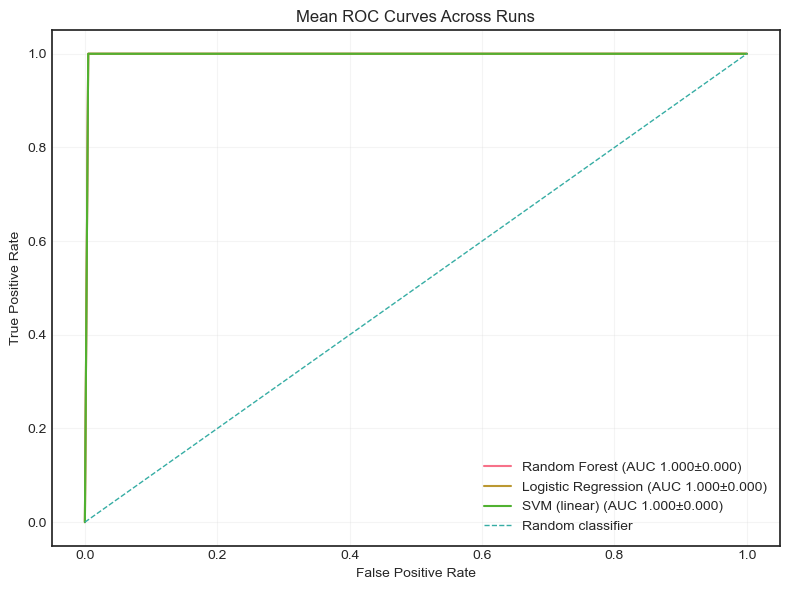

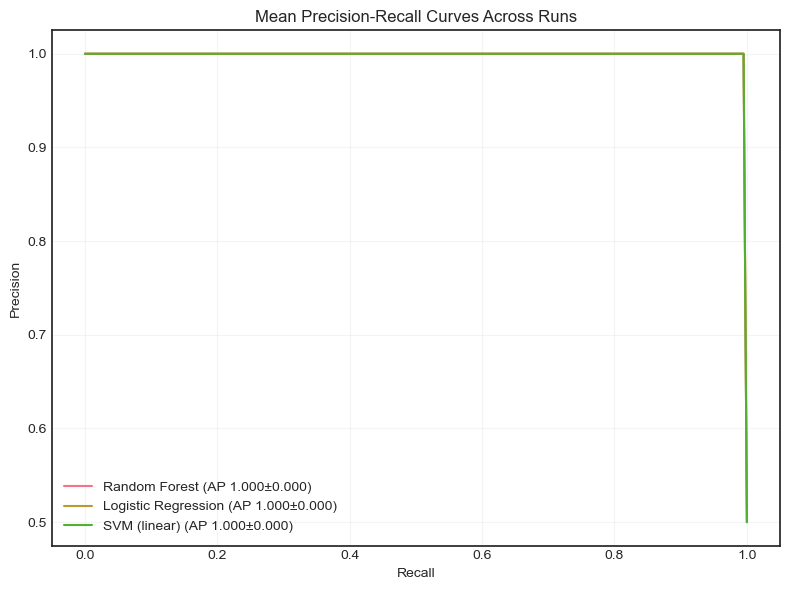

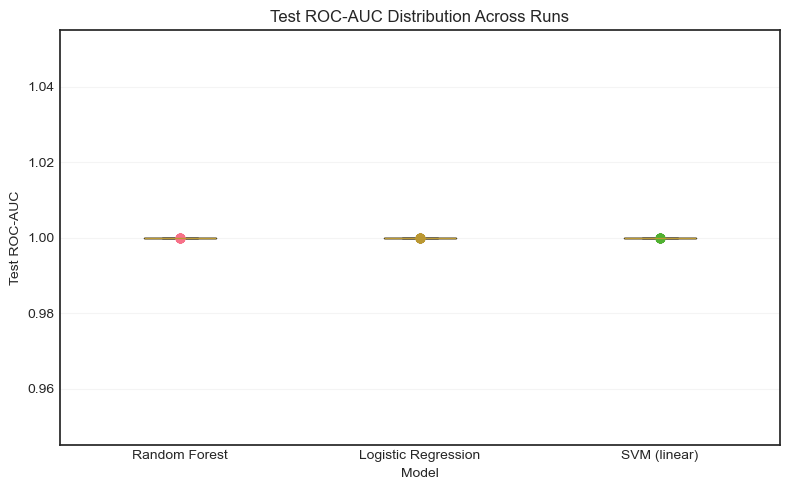

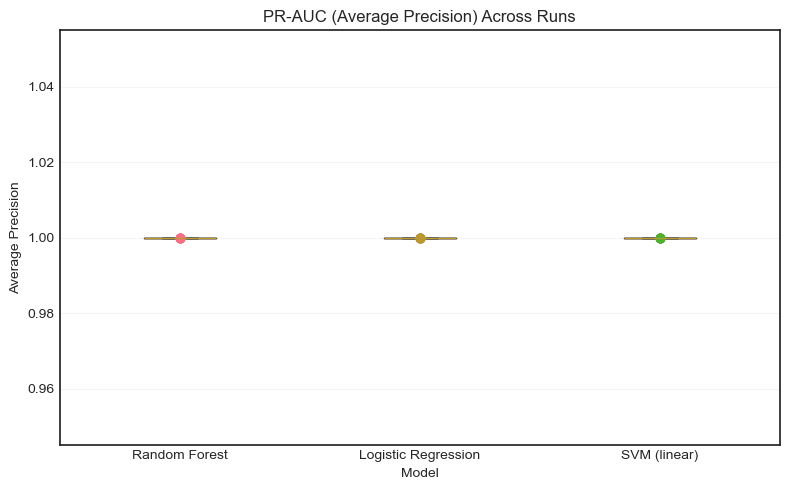

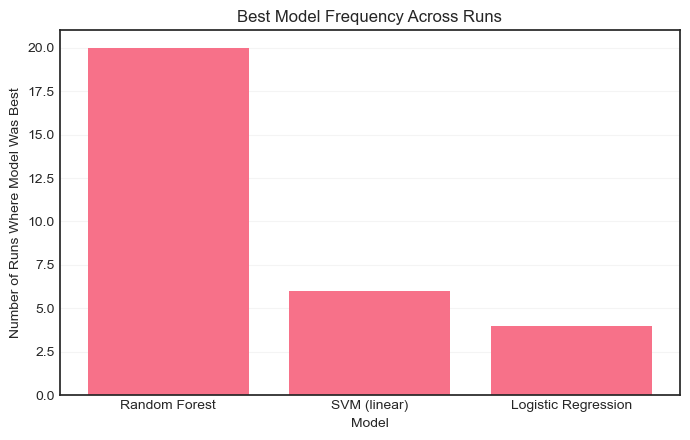


Saved:
- multi_run_model_results_30runs.csv
- multi_run_model_summary_30runs.csv
- multi_run_best_model_counts_30runs.csv

Stored Random Forest models for ranking: 30

Ready for next cell:
- results_df, summary, best_model_counts
- best_models_per_run (per-run best model + scaler + feature cols)
- rf_models_per_run (per-run fitted RF models for averaged ranking)
- all_feature_df (all nodes, no prox/distance)


In [19]:
# ============================================================
# MULTI-RUN VERSION OF THE ORIGINAL MODEL (REPRODUCIBLE + PLOTS)
#
# What this version does:
# - Runs once per negative set (expected: 30 sets)
# - Uses fixed seeds so results stay the same across reruns
# - Prints per-run performance
# - Stores per-run best model + scaler + feature cols for ranking later
# - Stores fitted Random Forest model from each run for averaged RF ranking later
# - Builds all_feature_df once for scoring all nodes later
# - metrics: ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1
# - Plots mean ROC and mean PR curves across runs for each model
# - Plots boxplots for test ROC-AUC and PR-AUC across runs
# - Plots best-model frequency across runs
# ============================================================

import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score,
    roc_curve,
    precision_recall_curve
)

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# -----------------------------
# Preconditions
# -----------------------------
if "negative_gene_sets" not in globals():
    raise RuntimeError("negative_gene_sets not found. Run negative sampling cell first.")
if "positive_genes" not in globals():
    raise RuntimeError("positive_genes not found.")
if "G" not in globals():
    raise RuntimeError("G not found. Build network first.")

N_RUNS = len(negative_gene_sets)
EXPECTED_RUNS = 30
SPLIT_SEED = 42
CV_SEED = 42
N_SPLITS_CV = 3

if N_RUNS != EXPECTED_RUNS:
    print(f"Warning: expected {EXPECTED_RUNS} negative sets, but found {N_RUNS}. Running with {N_RUNS} sets.")

print(f"=== RUNNING ORIGINAL MODEL FOR {N_RUNS} NEGATIVE SETS ===")

# -----------------------------
# Precompute centralities ONCE
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}

try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}

clust = nx.clustering(G)

# only include distance/prox features if dist_to_pos already exists
USE_DIST_PROX = "dist_to_pos" in globals()
PROX_ALPHA = 0.7

def extract_gene_features_clean(graph, gene):
    gene = str(gene)
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    row = {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)),
        "max_neighbor_degree": float(np.max(neighbor_degrees)),
        "avg_edge_weight": float(np.mean(neighbor_weights)),
        "max_edge_weight": float(np.max(neighbor_weights)),
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }

    pos_neighbors = [n for n in neighbors if graph.nodes[n].get("positive", 0) == 1]
    pos_weights = [float(graph[gene][n].get("weight", 1.0)) for n in pos_neighbors] if pos_neighbors else []
    total_w = float(np.sum(neighbor_weights))
    pos_w_sum = float(np.sum(pos_weights)) if pos_weights else 0.0
    row["pos_weight_fraction"] = pos_w_sum / (total_w + 1e-9)

    if USE_DIST_PROX:
        d = dist_to_pos.get(gene, np.inf)
        row["distance_to_positive"] = float(d) if not np.isinf(d) else np.inf
        row["prox"] = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    return row

# -----------------------------
# Build all_feature_df ONCE
# - keeps prox/distance out on purpose for later ranking
# -----------------------------
if "all_feature_df" not in globals():
    rows_all = []
    for g in sorted(G.nodes()):
        r = extract_gene_features_clean(G, g)
        if r is not None:
            r.pop("prox", None)
            r.pop("distance_to_positive", None)
            rows_all.append(r)
    all_feature_df = pd.DataFrame(rows_all)

# -----------------------------
# Models
# -----------------------------
def make_models():
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=GLOBAL_SEED,
            n_jobs=1
        ),
        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            random_state=GLOBAL_SEED,
            max_iter=2000,
            C=0.1,
            solver="liblinear"
        ),
        "SVM (linear)": SVC(
            probability=False,
            class_weight="balanced",
            random_state=GLOBAL_SEED,
            kernel="linear",
            C=0.1
        )
    }

cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=CV_SEED)

# -----------------------------
# Helpers
# -----------------------------
def get_scores(model, X_eval):
    if hasattr(model, "decision_function"):
        return model.decision_function(X_eval)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    raise RuntimeError("Model does not support decision_function or predict_proba.")

# Common x-axes for mean curve plotting
mean_fpr = np.linspace(0, 1, 200)
mean_recall_grid = np.linspace(0, 1, 200)

# -----------------------------
# Storage
# -----------------------------
all_results = []
best_models_per_run = []
rf_models_per_run = []   # NEW: store fitted RF model from each run for ranking
curve_store = {
    "Random Forest": {"roc": [], "pr": []},
    "Logistic Regression": {"roc": [], "pr": []},
    "SVM (linear)": {"roc": [], "pr": []}
}

# ============================================================
# MAIN LOOP
# ============================================================
for run_id, negative_genes in enumerate(negative_gene_sets):
    print(f"\n================ RUN {run_id} ================")

    positive_genes_list = sorted(list(map(str, positive_genes)))
    negative_genes_list = sorted(list(map(str, negative_genes)))

    all_labeled = positive_genes_list + negative_genes_list
    genes_in_graph = [g for g in all_labeled if str(g) in G]

    missing = sorted(set(map(str, all_labeled)) - set(map(str, genes_in_graph)))
    if missing:
        print(f"Note: {len(missing)} labeled genes not found in graph (dropped).")

    # -----------------------------
    # Feature DF for labeled genes only
    # -----------------------------
    rows = []
    for g in genes_in_graph:
        r = extract_gene_features_clean(G, g)
        if r is not None:
            rows.append(r)

    feature_df = pd.DataFrame(rows)
    pos_set = set(positive_genes_list)
    feature_df["label"] = feature_df["gene"].astype(str).apply(lambda g: 1 if g in pos_set else 0)

    if feature_df.empty:
        print("Warning: empty feature_df for this run. Skipping.")
        continue

    # -----------------------------
    # Data prep
    # -----------------------------
    X = feature_df.drop(columns=["gene", "label"]).replace([np.inf, -np.inf], np.nan).fillna(0)
    y = feature_df["label"].astype(int).values
    genes = feature_df["gene"].astype(str).values

    X_train, X_test, y_train, y_test, genes_train, genes_test = train_test_split(
        X, y, genes,
        test_size=0.2,
        random_state=SPLIT_SEED,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Keep original no-prox training logic
    drop_cols = [c for c in ["prox", "distance_to_positive"] if c in X_train.columns]
    if drop_cols:
        X_train_noprox = X_train.drop(columns=drop_cols)
        X_test_noprox = X_test.drop(columns=drop_cols)

        scaler_np = StandardScaler()
        X_train_scaled_noprox = scaler_np.fit_transform(X_train_noprox)
        X_test_scaled_noprox = scaler_np.transform(X_test_noprox)
    else:
        X_train_noprox = X_train
        X_test_noprox = X_test
        scaler_np = scaler
        X_train_scaled_noprox = X_train_scaled
        X_test_scaled_noprox = X_test_scaled

    # -----------------------------
    # Train + evaluate
    # -----------------------------
    models = make_models()
    cv_means = {}

    for name, model in models.items():
        use_scaled = isinstance(model, (LogisticRegression, SVC))

        X_cv = X_train_scaled_noprox if use_scaled else X_train_noprox
        X_eval = X_test_scaled_noprox if use_scaled else X_test_noprox

        cv_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="roc_auc")

        model.fit(X_cv, y_train)

        # Save fitted RF model from this run for later averaged ranking
        if name == "Random Forest":
            rf_models_per_run.append({
                "run_id": run_id,
                "model_name": name,
                "model": model,
                "use_scaled": bool(use_scaled),
                "scaler_used": scaler_np,
                "train_feature_cols_used": list(X_train_noprox.columns),
                "positive_genes_list": positive_genes_list,
                "negative_genes_list": negative_genes_list
            })

        y_pred = model.predict(X_eval)
        y_score = get_scores(model, X_eval)

        test_auc = float(roc_auc_score(y_test, y_score))
        test_ap = float(average_precision_score(y_test, y_score))
        test_acc = float(accuracy_score(y_test, y_pred))

        p, r, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="binary", zero_division=0
        )

        all_results.append({
            "run": run_id,
            "model": name,
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_pos_train": int(np.sum(y_train)),
            "n_pos_test": int(np.sum(y_test)),
            "cv_auc_mean": float(cv_scores.mean()),
            "cv_auc_std": float(cv_scores.std()),
            "test_auc": test_auc,
            "test_ap": test_ap,
            "accuracy": test_acc,
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1)
        })

        cv_means[name] = float(cv_scores.mean())

        # Store ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_score)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        curve_store[name]["roc"].append(interp_tpr)

        # Store PR curve
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
        recall_curve_rev = recall_curve[::-1]
        precision_curve_rev = precision_curve[::-1]
        interp_prec = np.interp(mean_recall_grid, recall_curve_rev, precision_curve_rev)
        curve_store[name]["pr"].append(interp_prec)

        print(
            f"{name:18s} | CV AUC {cv_scores.mean():.3f}±{cv_scores.std():.3f} "
            f"| Test AUC {test_auc:.3f} | AP {test_ap:.3f} | "
            f"Acc {test_acc:.3f} | P {p:.3f} R {r:.3f} F1 {f1:.3f}"
        )

    # -----------------------------
    # Pick best model by CV mean
    # -----------------------------
    best_model_name = max(cv_means, key=cv_means.get)
    best_model = make_models()[best_model_name]
    best_model_scaled = best_model_name in ["Logistic Regression", "SVM (linear)"]

    X_fit_best = X_train_scaled_noprox if best_model_scaled else X_train_noprox
    best_model.fit(X_fit_best, y_train)

    best_models_per_run.append({
        "run_id": run_id,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "best_model_scaled": bool(best_model_scaled),
        "scaler_used": scaler_np,
        "train_feature_cols_used": list(X_train_noprox.columns),
        "y_train": y_train,
        "positive_genes_list": positive_genes_list,
        "negative_genes_list": negative_genes_list
    })

# ============================
# SUMMARY TABLES
# ============================
results_df = pd.DataFrame(all_results)

print("\n=== SUMMARY ACROSS RUNS ===")
summary = (
    results_df
    .groupby("model")
    .agg(
        runs=("run", "nunique"),
        cv_auc_mean=("cv_auc_mean", "mean"),
        cv_auc_std=("cv_auc_mean", "std"),
        test_auc_mean=("test_auc", "mean"),
        test_auc_std=("test_auc", "std"),
        test_ap_mean=("test_ap", "mean"),
        test_ap_std=("test_ap", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .reset_index()
    .round(3)
    .sort_values("f1_mean", ascending=False)
)

print(summary.to_string(index=False))

# Best-model frequency across runs
best_model_counts = (
    pd.DataFrame(best_models_per_run)["best_model_name"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="n_best_runs")
)

print("\n=== BEST MODEL COUNT ACROSS RUNS ===")
print(best_model_counts.to_string(index=False))

# ============================
# PLOTS: MEAN ROC / PR CURVES
# ============================
plt.figure(figsize=(8, 6))
for model_name, d in curve_store.items():
    if len(d["roc"]) == 0:
        continue
    mean_tpr = np.mean(np.vstack(d["roc"]), axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(np.vstack(d["roc"]), axis=0)

    auc_mean = results_df.loc[results_df["model"] == model_name, "test_auc"].mean()
    auc_std = results_df.loc[results_df["model"] == model_name, "test_auc"].std()

    plt.plot(mean_fpr, mean_tpr, label=f"{model_name} (AUC {auc_mean:.3f}±{auc_std:.3f})")
    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curves Across Runs")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, d in curve_store.items():
    if len(d["pr"]) == 0:
        continue
    mean_prec = np.mean(np.vstack(d["pr"]), axis=0)
    std_prec = np.std(np.vstack(d["pr"]), axis=0)

    ap_mean = results_df.loc[results_df["model"] == model_name, "test_ap"].mean()
    ap_std = results_df.loc[results_df["model"] == model_name, "test_ap"].std()

    plt.plot(mean_recall_grid, mean_prec, label=f"{model_name} (AP {ap_mean:.3f}±{ap_std:.3f})")
    plt.fill_between(
        mean_recall_grid,
        np.maximum(mean_prec - std_prec, 0),
        np.minimum(mean_prec + std_prec, 1),
        alpha=0.15
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Mean Precision-Recall Curves Across Runs")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================
# PLOTS: BOXPLOTS ACROSS RUNS
# ============================
model_order = ["Random Forest", "Logistic Regression", "SVM (linear)"]

auc_data = [
    results_df.loc[results_df["model"] == m, "test_auc"].values
    for m in model_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(auc_data, tick_labels=model_order, showfliers=True)
for i, m in enumerate(model_order, start=1):
    yvals = results_df.loc[results_df["model"] == m, "test_auc"].values
    xvals = np.full_like(yvals, i, dtype=float)
    plt.plot(xvals, yvals, "o", alpha=0.35)
plt.title("Test ROC-AUC Distribution Across Runs")
plt.xlabel("Model")
plt.ylabel("Test ROC-AUC")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

ap_data = [
    results_df.loc[results_df["model"] == m, "test_ap"].values
    for m in model_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(ap_data, tick_labels=model_order, showfliers=True)
for i, m in enumerate(model_order, start=1):
    yvals = results_df.loc[results_df["model"] == m, "test_ap"].values
    xvals = np.full_like(yvals, i, dtype=float)
    plt.plot(xvals, yvals, "o", alpha=0.35)
plt.title("PR-AUC (Average Precision) Across Runs")
plt.xlabel("Model")
plt.ylabel("Average Precision")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# ============================
# PLOT: BEST MODEL FREQUENCY
# ============================
plt.figure(figsize=(7, 4.5))
plt.bar(best_model_counts["model"], best_model_counts["n_best_runs"])
plt.title("Best Model Frequency Across Runs")
plt.xlabel("Model")
plt.ylabel("Number of Runs Where Model Was Best")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# ============================
# SAVE RESULTS
# ============================
results_df.to_csv("multi_run_model_results_30runs.csv", index=False)
summary.to_csv("multi_run_model_summary_30runs.csv", index=False)
best_model_counts.to_csv("multi_run_best_model_counts_30runs.csv", index=False)

print("\nSaved:")
print("- multi_run_model_results_30runs.csv")
print("- multi_run_model_summary_30runs.csv")
print("- multi_run_best_model_counts_30runs.csv")

# ============================
# Compatibility variables
# ============================
best_model = best_models_per_run[-1]["best_model"]
best_model_scaled = best_models_per_run[-1]["best_model_scaled"]
scaler_used = best_models_per_run[-1]["scaler_used"]
train_feature_cols_used = best_models_per_run[-1]["train_feature_cols_used"]
y_train = best_models_per_run[-1]["y_train"]
positive_genes_list = best_models_per_run[-1]["positive_genes_list"]
negative_genes_list = best_models_per_run[-1]["negative_genes_list"]

print(f"\nStored Random Forest models for ranking: {len(rf_models_per_run)}")

print("\nReady for next cell:")
print("- results_df, summary, best_model_counts")
print("- best_models_per_run (per-run best model + scaler + feature cols)")
print("- rf_models_per_run (per-run fitted RF models for averaged ranking)")
print("- all_feature_df (all nodes, no prox/distance)")

=== AVERAGED RANDOM FOREST RANKING ACROSS 30 RUNS (NO PROX FEATURES) ===
Grouping mode: UNION of negatives across 30 runs
Scoring mode: MEAN over 30 Random Forest runs

Unlabeled genes: 659
Unique unlabeled scores: 611
Top score: 1.000000 | Unlabeled genes at top score: 24
Unlabeled rows with duplicated feature vectors (RUN 0 feature space): 2 / 659

Most frequent unlabeled score values (top 10):
model_score
1.000000    24
0.000000     6
0.998097     5
0.998264     3
0.999069     3
0.943960     2
0.154210     2
0.000125     2
0.077817     2
0.755818     2


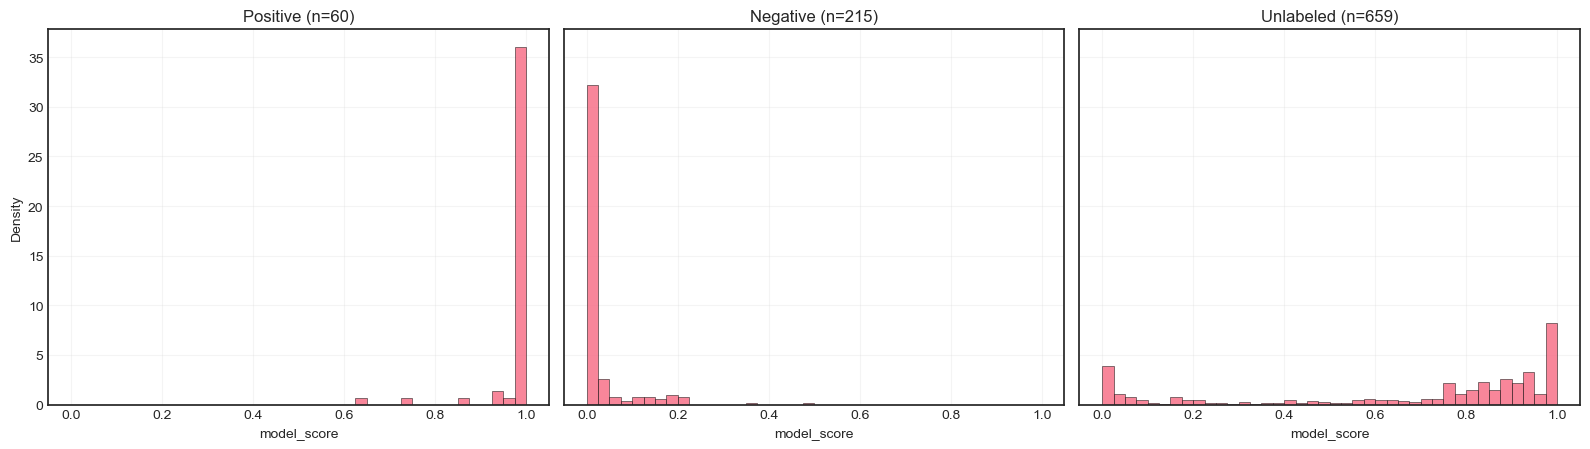


Top 20 unlabeled genes ranked by averaged Random Forest score:
 rank     gene  model_score  model_score_std  model_score_min  model_score_max  pos_weight_fraction  degree  max_neighbor_degree
    1      DBH          1.0              0.0              1.0              1.0             0.586829      17                 55.0
    2    CTLA4          1.0              0.0              1.0              1.0             0.538137      17                 67.0
    3    PTGS2          1.0              0.0              1.0              1.0             0.534306      21                 87.0
    4     CNTF          1.0              0.0              1.0              1.0             0.522258      18                 87.0
    5 SERPINE1          1.0              0.0              1.0              1.0             0.520095      21                 67.0
    6     FGF5          1.0              0.0              1.0              1.0             0.492614      18                 87.0
    7     GHRH          1.0      

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== AVERAGED RANDOM FOREST RANKING ACROSS 30 RUNS (NO PROX FEATURES) ===")

# -----------------------------
# 0) Preconditions from multi-run training
# -----------------------------
if "rf_models_per_run" not in globals() or len(rf_models_per_run) == 0:
    raise NameError("rf_models_per_run not found (or empty). Run the revised multi-run training cell first.")
if "G" not in globals():
    raise NameError("G not found. Build the network first.")
if "all_feature_df" not in globals() or all_feature_df is None or len(all_feature_df) == 0:
    raise NameError("all_feature_df not found. It should be built in the multi-run training cell.")

# -----------------------------
# Config
# -----------------------------
RUN_ID = 0                     # only used if SCORE_MODE == "single"
SCORE_MODE = "mean"            # "single" or "mean"
NEG_GROUP_MODE = "union"       # "union" or "single_run"
OUT_PATH = "Results/MDD_RF_mean_30runs_results.csv"

# -----------------------------
# 1) Pick RF run(s) to use
# -----------------------------
n_runs = len(rf_models_per_run)
if RUN_ID < 0 or RUN_ID >= n_runs:
    raise ValueError(f"RUN_ID must be in [0, {n_runs-1}]")

info0 = rf_models_per_run[RUN_ID]
train_feature_cols_run0 = list(info0["train_feature_cols_used"])

# -----------------------------
# 2) Define grouping
# -----------------------------
positive_set = set(map(str, positive_genes))

if NEG_GROUP_MODE == "single_run":
    negative_set = set(map(str, info0["negative_genes_list"]))
    print(f"Grouping mode: negatives from RUN {RUN_ID} only")
elif NEG_GROUP_MODE == "union":
    negative_set = set()
    for rinfo in rf_models_per_run:
        negative_set.update(map(str, rinfo["negative_genes_list"]))
    print(f"Grouping mode: UNION of negatives across {n_runs} runs")
else:
    raise ValueError("NEG_GROUP_MODE must be 'union' or 'single_run'")

def assign_group(g):
    g = str(g)
    if g in positive_set:
        return "positive"
    if g in negative_set:
        return "negative"
    return "unlabeled"

# -----------------------------
# 3) Prepare base dataframe
# -----------------------------
all_df = all_feature_df.copy()
all_df["gene"] = all_df["gene"].astype(str)
all_df["group"] = all_df["gene"].apply(assign_group)

# -----------------------------
# 4) Score all nodes with RF model(s)
# -----------------------------
def _score_with_rf(run_info, X_feat_df):
    model = run_info["model"]
    use_scaled = bool(run_info["use_scaled"])
    scaler = run_info["scaler_used"]

    X_eval = scaler.transform(X_feat_df.values) if use_scaled else X_feat_df.values

    # For RF we expect predict_proba, but keep a fallback just in case
    if hasattr(model, "predict_proba"):
        s = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X_eval)
    else:
        raise RuntimeError("Stored RF model does not support predict_proba or decision_function.")

    return np.asarray(s, dtype=float)

if SCORE_MODE == "single":
    cols = list(info0["train_feature_cols_used"])
    X_feat = all_df.set_index("gene").reindex(columns=cols, fill_value=0).copy()
    X_feat = X_feat.replace([np.inf, -np.inf], np.nan).fillna(0)

    missing_cols = [c for c in cols if c not in all_feature_df.columns]
    if missing_cols:
        print(f"Note: {len(missing_cols)} training feature cols missing in all_feature_df -> filled with 0")

    scores_all = _score_with_rf(info0, X_feat)
    all_df["model_score"] = scores_all
    print(f"Scoring mode: SINGLE RF run {RUN_ID}")

elif SCORE_MODE == "mean":
    score_mat = []

    for rinfo in rf_models_per_run:
        cols_r = list(rinfo["train_feature_cols_used"])
        X_feat_r = all_df.set_index("gene").reindex(columns=cols_r, fill_value=0).copy()
        X_feat_r = X_feat_r.replace([np.inf, -np.inf], np.nan).fillna(0)

        scores_r = _score_with_rf(rinfo, X_feat_r)
        score_mat.append(scores_r)

    score_mat = np.vstack(score_mat)   # shape: (n_runs, n_genes)

    all_df["model_score_mean"] = score_mat.mean(axis=0)
    all_df["model_score_std"] = score_mat.std(axis=0)
    all_df["model_score_min"] = score_mat.min(axis=0)
    all_df["model_score_max"] = score_mat.max(axis=0)

    # Use mean RF score for ranking and plots
    all_df["model_score"] = all_df["model_score_mean"]

    print(f"Scoring mode: MEAN over {n_runs} Random Forest runs")

else:
    raise ValueError("SCORE_MODE must be 'single' or 'mean'.")

# -----------------------------
# 5) Tie diagnostics
# -----------------------------
unl = all_df[all_df["group"] == "unlabeled"].copy()
n_unl = len(unl)
n_unique = unl["model_score"].nunique(dropna=False)
top_score = float(unl["model_score"].max()) if n_unl > 0 else np.nan
n_at_top = int((unl["model_score"] == top_score).sum()) if n_unl > 0 else 0

# duplicated feature vectors among unlabeled (based on RUN 0 feature space)
X_feat_run0 = all_df.set_index("gene").reindex(columns=train_feature_cols_run0, fill_value=0).copy()
X_feat_run0 = X_feat_run0.replace([np.inf, -np.inf], np.nan).fillna(0)

dup_mask = X_feat_run0.loc[unl["gene"].values].duplicated(keep=False) if n_unl > 0 else pd.Series([], dtype=bool)
n_dup = int(dup_mask.sum()) if n_unl > 0 else 0

print(f"\nUnlabeled genes: {n_unl}")
print(f"Unique unlabeled scores: {n_unique}")
print(f"Top score: {top_score:.6f} | Unlabeled genes at top score: {n_at_top}")
print(f"Unlabeled rows with duplicated feature vectors (RUN 0 feature space): {n_dup} / {n_unl}")

if n_unl > 0:
    print("\nMost frequent unlabeled score values (top 10):")
    print(unl["model_score"].value_counts().head(10).to_string())

# -----------------------------
# 6) Score distribution plots
# -----------------------------
pos_scores = all_df.loc[all_df["group"] == "positive", "model_score"].values
neg_scores = all_df.loc[all_df["group"] == "negative", "model_score"].values
unl_scores = all_df.loc[all_df["group"] == "unlabeled", "model_score"].values

all_scores = np.concatenate([pos_scores, neg_scores, unl_scores]) if len(all_df) else np.array([])
if len(all_scores) == 0:
    raise RuntimeError("No scores computed (all_scores empty).")

lo, hi = np.quantile(all_scores, [0.01, 0.99])
if lo == hi:
    lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
pad = 0.05 * (hi - lo + 1e-9)
x_min, x_max = lo - pad, hi + pad
bins = np.linspace(x_min, x_max, 45)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)

axes[0].hist(pos_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Positive (n={len(pos_scores)})")
axes[0].set_xlabel("model_score")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)

axes[1].hist(neg_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Negative (n={len(neg_scores)})")
axes[1].set_xlabel("model_score")
axes[1].grid(alpha=0.2)

axes[2].hist(unl_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[2].set_title(f"Unlabeled (n={len(unl_scores)})")
axes[2].set_xlabel("model_score")
axes[2].grid(alpha=0.2)

for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Ranked candidates
# -----------------------------
rank_df = all_df[all_df["group"] == "unlabeled"][["gene", "model_score"]].copy()

# Add tie-breakers if available in all_feature_df
tie_cols = [c for c in ["pos_weight_fraction", "degree", "max_neighbor_degree"] if c in all_df.columns]
for c in tie_cols:
    rank_df[c] = all_df.loc[rank_df.index, c].values

# If mean scoring, include stability diagnostics
if SCORE_MODE == "mean":
    rank_df["model_score_std"] = all_df.loc[rank_df.index, "model_score_std"].values
    rank_df["model_score_min"] = all_df.loc[rank_df.index, "model_score_min"].values
    rank_df["model_score_max"] = all_df.loc[rank_df.index, "model_score_max"].values

    # Prefer higher mean score, then lower std, then tie-breakers
    sort_cols = ["model_score", "model_score_std"] + tie_cols + ["gene"]
    ascending = [False, True] + [False] * len(tie_cols) + [True]
else:
    sort_cols = ["model_score"] + tie_cols + ["gene"]
    ascending = [False] + [False] * len(tie_cols) + [True]

rank_df = rank_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)

print("\nTop 20 unlabeled genes ranked by averaged Random Forest score:")
show_cols = ["rank", "gene", "model_score"]
if SCORE_MODE == "mean":
    show_cols += ["model_score_std", "model_score_min", "model_score_max"]
show_cols += tie_cols
print(rank_df.head(20)[show_cols].to_string(index=False))

# -----------------------------
# 8) Outputs
# -----------------------------
rank_candidates_df = rank_df.copy()
scored_all_df = all_df.copy()

print("\nSaved in memory:")
print("- rank_candidates_df (unlabeled ranking)")
print("- scored_all_df (all nodes with group + RF score)")

rank_candidates_df.to_csv(OUT_PATH, index=False)
print(f"\nSaved unlabeled candidate genes to: {OUT_PATH}")

In [23]:
import numpy as np
import pandas as pd

print("=== SCORE DISTRIBUTION SUMMARY (UNLABELED GENES ONLY) ===")

# -----------------------------
# Preconditions
# -----------------------------
if "scored_all_df" not in globals():
    raise NameError("scored_all_df not found. Run the scoring cell first.")
if "model_score" not in scored_all_df.columns:
    raise NameError("model_score column not found in scored_all_df.")

# -----------------------------
# Select unlabeled genes
# -----------------------------
unl_df = scored_all_df[scored_all_df["group"] == "unlabeled"].copy()

if len(unl_df) == 0:
    raise RuntimeError("No unlabeled genes found.")

scores = unl_df["model_score"].astype(float).values

# -----------------------------
# Basic distribution statistics
# -----------------------------
summary = {
    "n_unlabeled": len(scores),
    "mean": np.mean(scores),
    "std": np.std(scores),
    "min": np.min(scores),
    "q25": np.quantile(scores, 0.25),
    "median": np.quantile(scores, 0.50),
    "q75": np.quantile(scores, 0.75),
    "max": np.max(scores),
    "q90": np.quantile(scores, 0.90),
    "q95": np.quantile(scores, 0.95),
    "q99": np.quantile(scores, 0.99),
}

summary_df = pd.DataFrame(summary, index=["value"]).T
summary_df["value"] = summary_df["value"].astype(float)

print("\n--- Distribution statistics (unlabeled genes) ---")
print(summary_df.round(6).to_string())

# -----------------------------
# Concentration diagnostics
# -----------------------------
q95 = summary["q95"]
q99 = summary["q99"]

prop_above_95 = np.mean(scores >= q95)
prop_above_99 = np.mean(scores >= q99)

print("\n--- Score concentration diagnostics ---")
print(f"Genes ≥ 95th percentile score: {prop_above_95:.3%}")
print(f"Genes ≥ 99th percentile score: {prop_above_99:.3%}")

# -----------------------------
# Optional: detect heavy tails
# -----------------------------
iqr = summary["q75"] - summary["q25"]
upper_fence = summary["q75"] + 1.5 * iqr
n_outliers = int(np.sum(scores > upper_fence))

print("\n--- Tail behavior ---")
print(f"IQR: {iqr:.6f}")
print(f"Upper fence (Q75 + 1.5*IQR): {upper_fence:.6f}")
print(f"High-score outliers above upper fence: {n_outliers} ({n_outliers / len(scores):.3%})")

print("\nDone. These statistics can be used to summarize score distributions in the Results section.")


=== SCORE DISTRIBUTION SUMMARY (UNLABELED GENES ONLY) ===

--- Distribution statistics (unlabeled genes) ---
                  value
n_unlabeled  659.000000
mean           0.681287
std            0.349755
min            0.000000
q25            0.463744
median         0.835066
q75            0.942677
max            1.000000
q90            0.997349
q95            0.999203
q99            1.000000

--- Score concentration diagnostics ---
Genes ≥ 95th percentile score: 5.008%
Genes ≥ 99th percentile score: 3.642%

--- Tail behavior ---
IQR: 0.478933
Upper fence (Q75 + 1.5*IQR): 1.661076
High-score outliers above upper fence: 0 (0.000%)

Done. These statistics can be used to summarize score distributions in the Results section.


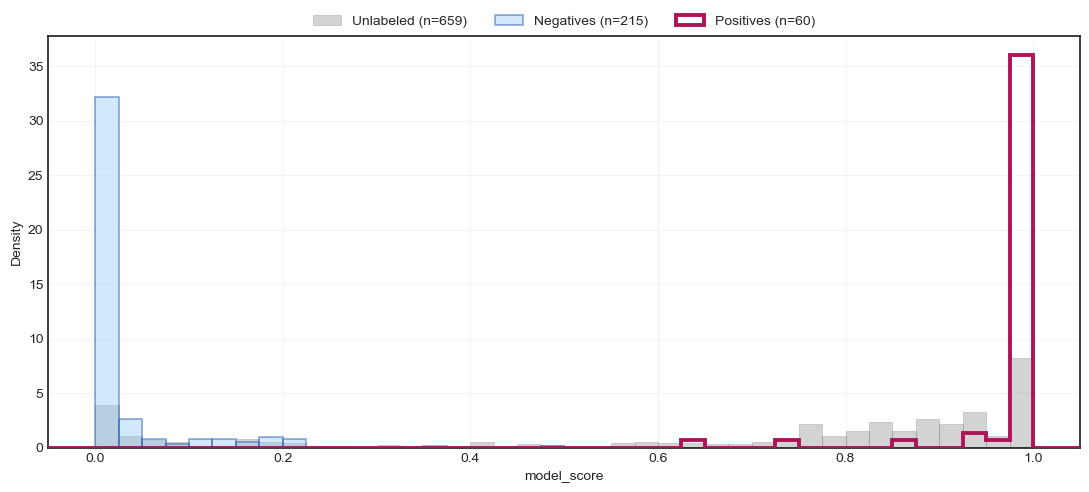

In [25]:
# =======================================================
# 5b) Combined overlay plot (final paper styling)
# =======================================================
COL_UNL_FILL = "#6E6E6E"    # dark gray (unlabeled)
COL_POS_EDGE = "#AD1457"    # dark pink margin (positives)
COL_NEG_FILL = "#90CAF9"    # light blue fill (negatives)
COL_NEG_EDGE = "#0D47A1"    # dark blue margin (negatives)

plt.figure(figsize=(11, 5))

# Unlabeled: dark gray filled
plt.hist(
    unl_scores,
    bins=bins,
    density=True,
    alpha=0.30,
    color=COL_UNL_FILL,
    edgecolor=COL_UNL_FILL,
    linewidth=0.6,
    label=f"Unlabeled (n={len(unl_scores)})",
    zorder=1,
)

# Negatives: blue filled with dark blue margin
plt.hist(
    neg_scores,
    bins=bins,
    density=True,
    alpha=0.40,
    color=COL_NEG_FILL,
    edgecolor=COL_NEG_EDGE,
    linewidth=1.4,
    label=f"Negatives (n={len(neg_scores)})",
    zorder=2,
)

# Positives: unfilled with dark pink margin
plt.hist(
    pos_scores,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.8,
    color=COL_POS_EDGE,
    label=f"Positives (n={len(pos_scores)})",
    zorder=4,
)

plt.xlim(x_min, x_max)
plt.xlabel("model_score")
plt.ylabel("Density")
plt.grid(alpha=0.2)

# Legend / description at upper center
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.savefig("Results/RandomForest.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Model performance:
# ============================================================
# ROC / PR CURVES FOR BASELINE MODELS ACROSS 10 NEGATIVE SETS
# - Uses the SAME train/test split logic as your baseline cell
# - Plots per-run ROC curves + a mean ROC curve (interpolated)
# - Also plots PR curves (often useful when classes are imbalanced)
# - Saves high-res PNGs suitable for thesis figures
#
# Notes:
# - Set MODELS_TO_PLOT to ["Random Forest"] if you only want RF.
# - If you keep LR/SVM in training but don’t want them in the thesis,
#   just exclude them from MODELS_TO_PLOT.
# ============================================================

import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# -----------------------------
# Preconditions (same spirit as your cell)
# -----------------------------
if "negative_gene_sets" not in globals():
    raise RuntimeError("negative_gene_sets not found. Run negative sampling cell first.")
if "positive_genes" not in globals():
    raise RuntimeError("positive_genes not found.")
if "G" not in globals():
    raise RuntimeError("G not found. Build network first.")

# -----------------------------
# Config
# -----------------------------
OUT_DIR = "figures_model_performance"
os.makedirs(OUT_DIR, exist_ok=True)

SPLIT_SEED = 42
TEST_SIZE = 0.2

# Choose what to show in thesis
MODELS_TO_PLOT = ["Random Forest"]  # or ["Random Forest", "Logistic Regression", "SVM (linear)"]

# For smooth "mean ROC" curve
FPR_GRID = np.linspace(0.0, 1.0, 200)

# -----------------------------
# Feature extraction (reuse your exact function, but require it exists)
# -----------------------------
# If extract_gene_features_clean is already defined in your notebook, this will use it.
# Otherwise, we raise an error so you don't accidentally use different features.
if "extract_gene_features_clean" not in globals():
    raise RuntimeError("extract_gene_features_clean not found. Run your baseline feature cell first.")

def make_models():
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ),
        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=2000,
            C=0.1,
            solver="liblinear"
        ),
        "SVM (linear)": SVC(
            probability=False,
            class_weight="balanced",
            random_state=42,
            kernel="linear",
            C=0.1
        )
    }

# -----------------------------
# Helper: fit + get scores
# -----------------------------
def fit_and_score(model, X_train, y_train, X_test, use_scaled):
    if use_scaled:
        scaler = StandardScaler()
        X_train_ = scaler.fit_transform(X_train)
        X_test_ = scaler.transform(X_test)
    else:
        X_train_ = X_train
        X_test_ = X_test

    model.fit(X_train_, y_train)

    # Continuous score
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_)
    else:
        y_score = model.predict_proba(X_test_)[:, 1]

    return y_score

# -----------------------------
# Build & cache labeled feature_df per run (same as your baseline)
# -----------------------------
positive_genes_list = list(map(str, positive_genes))
pos_set = set(positive_genes_list)

def build_labeled_feature_df(negative_genes):
    negative_genes_list = list(map(str, negative_genes))
    all_labeled = positive_genes_list + negative_genes_list

    genes_in_graph = [g for g in all_labeled if str(g) in G]
    rows = []
    for g in genes_in_graph:
        r = extract_gene_features_clean(G, g)
        if r is not None:
            rows.append(r)

    df = pd.DataFrame(rows)
    df["label"] = df["gene"].astype(str).apply(lambda g: 1 if g in pos_set else 0)

    X = (
        df.drop(columns=["gene", "label"])
          .replace([np.inf, -np.inf], np.nan)
          .fillna(0)
    )
    y = df["label"].astype(int).values
    return X, y

# ============================================================
# MAIN: loop models, aggregate curves across runs
# ============================================================
models_all = make_models()

for model_name in MODELS_TO_PLOT:
    if model_name not in models_all:
        raise ValueError(f"Unknown model_name: {model_name}")

    model_template = models_all[model_name]

    # Storage for mean curves
    tprs = []
    aucs = []
    prs = []
    aps = []

    plt.figure()
    for run_id, negative_genes in enumerate(negative_gene_sets):
        X, y = build_labeled_feature_df(negative_genes)

        # Same split as baseline cell
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=SPLIT_SEED,
            stratify=y
        )

        # Use scaling for LR/SVM only (RF does not need scaling)
        use_scaled = model_name in ["Logistic Regression", "SVM (linear)"]

        # Fresh copy of model each run (avoid carry-over state)
        model = make_models()[model_name]

        y_score = fit_and_score(model, X_train, y_train, X_test, use_scaled=use_scaled)

        # ROC
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        # Interpolate onto a common grid for mean ROC
        tpr_interp = np.interp(FPR_GRID, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

        # Plot per-run ROC lightly
        plt.plot(fpr, tpr, alpha=0.25)

    # Mean ROC
    mean_tpr = np.mean(np.vstack(tprs), axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(FPR_GRID, mean_tpr, linewidth=2.0)
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves Across Negative Samples: {model_name}\nMean AUC = {mean_auc:.3f} ± {std_auc:.3f}")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"roc_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png")
    plt.savefig(out_path, dpi=300)
    plt.close()

    # -----------------------------
    # PR Curves (often useful too)
    # -----------------------------
    RECALL_GRID = np.linspace(0.0, 1.0, 200)
    precs_interp_all = []

    plt.figure()
    for run_id, negative_genes in enumerate(negative_gene_sets):
        X, y = build_labeled_feature_df(negative_genes)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=SPLIT_SEED,
            stratify=y
        )

        use_scaled = model_name in ["Logistic Regression", "SVM (linear)"]
        model = make_models()[model_name]
        y_score = fit_and_score(model, X_train, y_train, X_test, use_scaled=use_scaled)

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        aps.append(ap)

        # PR curve is precision vs recall; interpolate precision over a common recall grid
        # Need recall increasing for interp; sklearn returns recall decreasing sometimes depending on thresholding,
        # so we sort by recall.
        order = np.argsort(recall)
        recall_sorted = recall[order]
        precision_sorted = precision[order]

        prec_interp = np.interp(RECALL_GRID, recall_sorted, precision_sorted)
        precs_interp_all.append(prec_interp)

        plt.plot(recall, precision, alpha=0.25)

    mean_prec = np.mean(np.vstack(precs_interp_all), axis=0)
    mean_ap = np.mean(aps)
    std_ap = np.std(aps)

    plt.plot(RECALL_GRID, mean_prec, linewidth=2.0)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curves Across Negative Samples: {model_name}\nMean AP = {mean_ap:.3f} ± {std_ap:.3f}")
    plt.tight_layout()
    #plt.print()

    out_path = os.path.join(OUT_DIR, f"pr_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png")
    plt.savefig(out_path, dpi=300)
    plt.close()

print(f"Saved figures to: {OUT_DIR}")

# Optional: list what was saved
for fn in sorted(os.listdir(OUT_DIR)):
    print(" -", fn)




Saved figures to: figures_model_performance
 - pr_Random_Forest.png
 - roc_Random_Forest.png
